# Assignment 4 Optional Bonus: End-to-End Workflow

This notebook solves the Optional Bonus only. 

The goal is to use one tabular classification dataset and apply the full workflow:

Data Cleaning -> ML Pipeline -> Imbalance Handling -> Tabular Generative Model -> XAI

We use `classification_DATA.csv`, where the target is `loan_status`. This dataset is a good fit because it is numeric, mostly preprocessed, imbalanced, suitable for sklearn pipelines, and meaningful for explainability because loan-status models affect decisions about people.

Known target imbalance:

- Class 0: 34,993 samples, about 77.8%
- Class 1: 10,000 samples, about 22.2%

The main question is not only "which model scores best", but also how each workflow stage changes the result, the trade-offs, and the limitations.

## Imports and Configuration



In [1]:
from pathlib import Path
import os
import random
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, HTML

from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    PrecisionRecallDisplay,
    recall_score,
    RocCurveDisplay,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from imblearn.over_sampling import RandomOverSampler, SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline as ImbPipeline

import joblib

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="notebook")

RANDOM_STATE = 42
TARGET_COL = "loan_status"
TEST_SIZE = 0.20

DATA_PATH_CANDIDATES = [
    Path("classification_DATA.csv"),
    Path("data") / "classification_DATA.csv",
]
OUTPUT_DIR = Path("outputs")
MODEL_DIR = Path("models")
FIGURE_DIR = Path("figures")
REPORT_DIR = Path("reports")

for directory in [OUTPUT_DIR, MODEL_DIR, FIGURE_DIR, REPORT_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)

try:
    import tensorflow as tf
    from tensorflow import keras
    from tensorflow.keras import layers

    tf.random.set_seed(RANDOM_STATE)
    TF_AVAILABLE = True
    TF_IMPORT_ERROR = None
except Exception as exc:
    TF_AVAILABLE = False
    TF_IMPORT_ERROR = repr(exc)

try:
    import shap

    SHAP_AVAILABLE = True
    SHAP_IMPORT_ERROR = None
except Exception as exc:
    SHAP_AVAILABLE = False
    SHAP_IMPORT_ERROR = repr(exc)

try:
    from lime.lime_tabular import LimeTabularExplainer

    LIME_AVAILABLE = True
    LIME_IMPORT_ERROR = None
except Exception as exc:
    LIME_AVAILABLE = False
    LIME_IMPORT_ERROR = repr(exc)

try:
    import eli5

    ELI5_AVAILABLE = True
    ELI5_IMPORT_ERROR = None
except Exception as exc:
    ELI5_AVAILABLE = False
    ELI5_IMPORT_ERROR = repr(exc)

package_status = pd.DataFrame(
    [
        {"package": "tensorflow/keras", "available": TF_AVAILABLE, "error": TF_IMPORT_ERROR},
        {"package": "shap", "available": SHAP_AVAILABLE, "error": SHAP_IMPORT_ERROR},
        {"package": "lime", "available": LIME_AVAILABLE, "error": LIME_IMPORT_ERROR},
        {"package": "eli5", "available": ELI5_AVAILABLE, "error": ELI5_IMPORT_ERROR},
    ]
)
display(package_status)

,package,available,error
0,tensorflow/keras,True,None
1,shap,True,None
2,lime,True,None
3,eli5,True,None


## Data Loading and Quick Inspection

 Before modeling, we need to verify that the notebook is using the correct dataset and that the known facts match the actual file.



Loading dataset from: D:\SHARIF\TERM7\DATA\HW4\BONUS\classification_DATA.csv


,person_age,person_gender,person_income,person_emp_exp,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,...,interest_per_credit_score,default_interest_interaction,high_loan_burden,high_interest_rate,annual_interest_amount,young_applicant,low_income_applicant,high_income_applicant,short_credit_history,loan_status
0,22.0,0,71948.0,0,35000.0,16.02,0.49,3.0,561,0,...,0.028556,0.00,1,1,5607.00,1,0,0,0,1
1,21.0,0,12282.0,0,1000.0,11.14,0.08,2.0,504,1,...,0.022103,11.14,0,0,111.40,1,1,0,1,0
2,25.0,0,12438.0,3,5500.0,12.87,0.44,3.0,635,0,...,0.020268,0.00,1,0,707.85,0,1,0,0,1
3,23.0,0,79753.0,0,35000.0,15.23,0.44,2.0,675,0,...,0.022563,0.00,1,1,5330.50,1,0,0,1,1
4,24.0,1,66135.0,1,35000.0,14.27,0.53,4.0,586,0,...,0.024352,0.00,1,1,4994.50,1,0,0,0,1


Shape: (44993, 38)

DataFrame info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44993 entries, 0 to 44992
Data columns (total 38 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   person_age                      44993 non-null  float64
 1   person_gender                   44993 non-null  int64  
 2   person_income                   44993 non-null  float64
 3   person_emp_exp                  44993 non-null  int64  
 4   loan_amnt                       44993 non-null  float64
 5   loan_int_rate                   44993 non-null  float64
 6   loan_percent_income             44993 non-null  float64
 7   cb_person_cred_hist_length      44993 non-null  float64
 8   credit_score                    44993 non-null  int64  
 9   previous_loan_defaults_on_file  44993 non-null  int64  
 10  person_education_Associate      44993 non-null  int64  
 11  person_education_Bachelor       44993 non-null  int64  
 

,loan_status,count,percent
0,0,34993,77.77432
1,1,10000,22.22568


,dtype,count
0,int64,23
1,float64,15


,count,mean,std,min,25%,50%,75%,max
person_age,44993.0,27.748428,5.909737,20.000000,24.000000,26.000000,30.000000,9.400000e+01
person_gender,44993.0,0.551997,0.497294,0.000000,0.000000,1.000000,1.000000,1.000000e+00
person_income,44993.0,79908.447581,63322.132349,8000.000000,47195.000000,67046.000000,95778.000000,2.448661e+06
person_emp_exp,44993.0,5.394528,5.927159,0.000000,1.000000,4.000000,8.000000,7.600000e+01
loan_amnt,44993.0,9583.176761,6314.802655,500.000000,5000.000000,8000.000000,12237.000000,3.500000e+04
loan_int_rate,44993.0,11.006448,2.978985,5.420000,8.590000,11.010000,12.990000,2.000000e+01
loan_percent_income,44993.0,0.139736,0.087207,0.000000,0.070000,0.120000,0.190000,6.600000e-01
cb_person_cred_hist_length,44993.0,5.866557,3.877167,2.000000,3.000000,4.000000,8.000000,3.000000e+01
credit_score,44993.0,632.585713,50.402411,390.000000,601.000000,640.000000,670.000000,7.840000e+02
previous_loan_defaults_on_file,44993.0,0.507990,0.499942,0.000000,0.000000,1.000000,1.000000,1.000000e+00


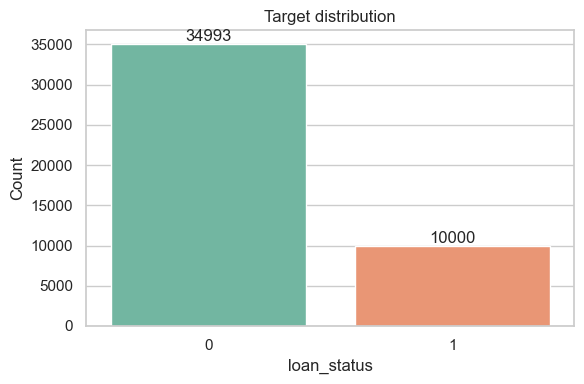

In [2]:
def load_dataset(path_candidates):
    for path in path_candidates:
        if path.exists():
            print(f"Loading dataset from: {path.resolve()}")
            return pd.read_csv(path), path
    searched = ", ".join(str(path) for path in path_candidates)
    raise FileNotFoundError(f"classification_DATA.csv was not found. Searched: {searched}")


raw_df, DATA_PATH = load_dataset(DATA_PATH_CANDIDATES)

display(raw_df.head())
print(f"Shape: {raw_df.shape}")
print("\nDataFrame info:")
raw_df.info()

missing_table = (
    raw_df.isna()
    .sum()
    .rename("missing_count")
    .to_frame()
    .assign(missing_percent=lambda d: 100 * d["missing_count"] / len(raw_df))
    .query("missing_count > 0")
    .sort_values("missing_count", ascending=False)
)
if missing_table.empty:
    print("\nNo missing values found.")
else:
    display(missing_table)

duplicate_count = int(raw_df.duplicated().sum())
print(f"Duplicate rows: {duplicate_count}")

target_distribution = (
    raw_df[TARGET_COL]
    .value_counts()
    .sort_index()
    .rename_axis(TARGET_COL)
    .reset_index(name="count")
)
target_distribution["percent"] = 100 * target_distribution["count"] / len(raw_df)
display(target_distribution)

dtype_summary = raw_df.dtypes.astype(str).value_counts().rename_axis("dtype").reset_index(name="count")
display(dtype_summary)

display(raw_df.describe().T)

fig, ax = plt.subplots(figsize=(6, 4))
sns.countplot(data=raw_df, x=TARGET_COL, ax=ax, palette="Set2")
ax.set_title("Target distribution")
ax.set_xlabel("loan_status")
ax.set_ylabel("Count")
for container in ax.containers:
    ax.bar_label(container)
fig.tight_layout()
fig.savefig(FIGURE_DIR / "target_distribution.png", dpi=160)
plt.show()

## Data Cleaning with pandas.pipe

Even when a dataset looks clean, a reproducible workflow should validate the target, data types, duplicates, binary indicators, and suspicious numeric ranges.



In [3]:
CLEANING_LOG = []
RANGE_WARNINGS = {}


def standardize_column_names(df):
    out = df.copy()
    out.columns = (
        out.columns
        .str.strip()
        .str.lower()
        .str.replace(" ", "_", regex=False)
        .str.replace("-", "_", regex=False)
    )
    CLEANING_LOG.append("Standardized column names with strip/lower/underscore rules.")
    return out


def validate_required_columns(df, required_columns):
    missing = [col for col in required_columns if col not in df.columns]
    if missing:
        raise ValueError(f"Missing required columns: {missing}")
    CLEANING_LOG.append(f"Required columns present: {required_columns}")
    return df


def validate_target_column(df, target_col):
    values = sorted(df[target_col].dropna().unique().tolist())
    if values != [0, 1]:
        raise ValueError(f"Expected binary target values [0, 1], found {values}")
    CLEANING_LOG.append(f"Target column {target_col!r} is binary with values {values}.")
    return df


def remove_duplicate_rows(df):
    before = len(df)
    out = df.drop_duplicates().copy()
    removed = before - len(out)
    CLEANING_LOG.append(f"Removed {removed} duplicate rows.")
    return out


def enforce_numeric_dtypes(df):
    out = df.copy()
    for col in out.columns:
        out[col] = pd.to_numeric(out[col], errors="raise")
    CLEANING_LOG.append("All columns were verified or converted as numeric.")
    return out


def detect_binary_indicator_columns(df, target_col):
    binary_cols = []
    for col in df.columns:
        if col == target_col:
            continue
        values = set(df[col].dropna().unique().tolist())
        if values.issubset({0, 1, 0.0, 1.0}):
            binary_cols.append(col)
    return binary_cols


def validate_binary_columns(df, binary_cols):
    invalid = {}
    for col in binary_cols:
        values = set(df[col].dropna().unique().tolist())
        if not values.issubset({0, 1, 0.0, 1.0}):
            invalid[col] = sorted(values)
    if invalid:
        raise ValueError(f"Binary indicator validation failed: {invalid}")
    CLEANING_LOG.append(f"Validated {len(binary_cols)} binary/indicator feature columns.")
    return df


def validate_numeric_ranges(df):
    checks = {
        "person_age": (18, 100),
        "person_income": (0, None),
        "person_emp_exp": (0, None),
        "loan_amnt": (0, None),
        "loan_int_rate": (0, 100),
        "loan_percent_income": (0, 1),
        "cb_person_cred_hist_length": (0, None),
        "credit_score": (300, 900),
        "annual_interest_amount": (0, None),
    }
    RANGE_WARNINGS.clear()
    for col, (low, high) in checks.items():
        if col not in df.columns:
            continue
        mask = pd.Series(False, index=df.index)
        if low is not None:
            mask = mask | (df[col] < low)
        if high is not None:
            mask = mask | (df[col] > high)
        count = int(mask.sum())
        if count:
            RANGE_WARNINGS[col] = count
    CLEANING_LOG.append(
        f"Checked numeric ranges. Warning columns: {RANGE_WARNINGS if RANGE_WARNINGS else 'none'}."
    )
    return df


def report_cleaning_summary(df):
    summary = {
        "rows": len(df),
        "columns": df.shape[1],
        "missing_values": int(df.isna().sum().sum()),
        "duplicate_rows": int(df.duplicated().sum()),
        "target_values": df[TARGET_COL].value_counts().sort_index().to_dict(),
        "range_warnings": RANGE_WARNINGS,
    }
    return summary


preview_df = standardize_column_names(raw_df)
required_columns = [TARGET_COL]
binary_indicator_cols = detect_binary_indicator_columns(preview_df, TARGET_COL)

CLEANING_LOG.clear()
cleaned_df = (
    raw_df
    .pipe(standardize_column_names)
    .pipe(validate_required_columns, required_columns=required_columns)
    .pipe(validate_target_column, target_col=TARGET_COL)
    .pipe(remove_duplicate_rows)
    .pipe(enforce_numeric_dtypes)
    .pipe(validate_numeric_ranges)
    .pipe(validate_binary_columns, binary_cols=binary_indicator_cols)
)

cleaning_summary = report_cleaning_summary(cleaned_df)
print("\n".join(f"- {item}" for item in CLEANING_LOG))
display(pd.DataFrame([cleaning_summary]))
print(f"Detected binary indicator columns ({len(binary_indicator_cols)}):")
print(binary_indicator_cols)

- Standardized column names with strip/lower/underscore rules.
- Required columns present: ['loan_status']
- Target column 'loan_status' is binary with values [0, 1].
- Removed 0 duplicate rows.
- All columns were verified or converted as numeric.
- Checked numeric ranges. Warning columns: none.
- Validated 20 binary/indicator feature columns.


,rows,columns,missing_values,duplicate_rows,target_values,range_warnings
0,44993,38,0,0,"{0: 34993, 1: 10000}",{}


Detected binary indicator columns (20):
['person_gender', 'previous_loan_defaults_on_file', 'person_education_associate', 'person_education_bachelor', 'person_education_doctorate', 'person_education_master', 'person_home_ownership_mortgage', 'person_home_ownership_other', 'person_home_ownership_own', 'loan_intent_debtconsolidation', 'loan_intent_education', 'loan_intent_homeimprovement', 'loan_intent_medical', 'loan_intent_venture', 'high_loan_burden', 'high_interest_rate', 'young_applicant', 'low_income_applicant', 'high_income_applicant', 'short_credit_history']


## Feature/Target Split and Train/Test Split

All later comparisons must use the same train/test split. Stratification preserves the class ratio in both sets.


In [4]:
X = cleaned_df.drop(columns=[TARGET_COL])
y = cleaned_df[TARGET_COL].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y,
)

split_distribution = pd.concat(
    {
        "full": y.value_counts(normalize=True).sort_index(),
        "train": y_train.value_counts(normalize=True).sort_index(),
        "test": y_test.value_counts(normalize=True).sort_index(),
    },
    axis=1,
)
split_counts = pd.concat(
    {
        "full_count": y.value_counts().sort_index(),
        "train_count": y_train.value_counts().sort_index(),
        "test_count": y_test.value_counts().sort_index(),
    },
    axis=1,
)
display(split_counts)
display((100 * split_distribution).round(2))

original_test_fingerprint = pd.util.hash_pandas_object(
    pd.concat([X_test.reset_index(drop=True), y_test.reset_index(drop=True)], axis=1),
    index=True,
).sum()
print(f"Untouched test-set fingerprint: {original_test_fingerprint}")

,full_count,train_count,test_count
loan_status,,,
0,34993,27994,6999
1,10000,8000,2000


,full,train,test
loan_status,,,
0,77.77,77.77,77.78
1,22.23,22.23,22.22


Untouched test-set fingerprint: 11753072571247675287


## Feature Grouping and Preprocessing

The dataset has continuous numeric columns and already encoded binary columns. We scale continuous columns but pass binary indicators through without one-hot encoding them again.


In [5]:
requested_continuous_cols = [
    "person_age",
    "person_income",
    "person_emp_exp",
    "loan_amnt",
    "loan_int_rate",
    "loan_percent_income",
    "cb_person_cred_hist_length",
    "credit_score",
    "log_person_income",
    "log_loan_amnt",
    "whole_loan_percent_income",
    "loan_credit",
    "interest_burden",
    "employment_experience_ratio",
    "interest_per_credit_score",
    "default_interest_interaction",
    "annual_interest_amount",
]

requested_binary_cols = [
    "person_gender",
    "previous_loan_defaults_on_file",
    "person_education_associate",
    "person_education_bachelor",
    "person_education_doctorate",
    "person_education_master",
    "person_home_ownership_mortgage",
    "person_home_ownership_other",
    "person_home_ownership_own",
    "loan_intent_debtconsolidation",
    "loan_intent_education",
    "loan_intent_homeimprovement",
    "loan_intent_medical",
    "loan_intent_venture",
    "high_loan_burden",
    "high_interest_rate",
    "young_applicant",
    "low_income_applicant",
    "high_income_applicant",
    "short_credit_history",
]

continuous_cols = [col for col in requested_continuous_cols if col in X.columns]
binary_cols = [col for col in requested_binary_cols if col in X.columns]

covered = set(continuous_cols) | set(binary_cols)
remaining_cols = [col for col in X.columns if col not in covered]
for col in remaining_cols:
    values = set(X[col].dropna().unique().tolist())
    if values.issubset({0, 1, 0.0, 1.0}):
        binary_cols.append(col)
    else:
        continuous_cols.append(col)

assert set(continuous_cols).isdisjoint(binary_cols)
assert set(continuous_cols) | set(binary_cols) == set(X.columns)

continuous_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

binary_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("continuous", continuous_pipeline, continuous_cols),
        ("binary", binary_pipeline, binary_cols),
    ],
    remainder="drop",
    verbose_feature_names_out=False,
)

print(f"Continuous columns ({len(continuous_cols)}): {continuous_cols}")
print(f"Binary/indicator columns ({len(binary_cols)}): {binary_cols}")

Continuous columns (17): ['person_age', 'person_income', 'person_emp_exp', 'loan_amnt', 'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length', 'credit_score', 'log_person_income', 'log_loan_amnt', 'whole_loan_percent_income', 'loan_credit', 'interest_burden', 'employment_experience_ratio', 'interest_per_credit_score', 'default_interest_interaction', 'annual_interest_amount']
Binary/indicator columns (20): ['person_gender', 'previous_loan_defaults_on_file', 'person_education_associate', 'person_education_bachelor', 'person_education_doctorate', 'person_education_master', 'person_home_ownership_mortgage', 'person_home_ownership_other', 'person_home_ownership_own', 'loan_intent_debtconsolidation', 'loan_intent_education', 'loan_intent_homeimprovement', 'loan_intent_medical', 'loan_intent_venture', 'high_loan_burden', 'high_interest_rate', 'young_applicant', 'low_income_applicant', 'high_income_applicant', 'short_credit_history']


## Evaluation Utilities

A reusable evaluator keeps the comparisons fair and consistent across all stages.



In [6]:
stage_results = []
fitted_models = {}


def positive_scores(model, X_eval):
    if hasattr(model, "predict_proba"):
        return model.predict_proba(X_eval)[:, 1]
    if hasattr(model, "decision_function"):
        raw_scores = model.decision_function(X_eval)
        return 1 / (1 + np.exp(-raw_scores))
    return model.predict(X_eval)


def evaluate_binary_model(stage, method, model, X_eval, y_eval, notes=""):
    y_pred = model.predict(X_eval)
    y_score = positive_scores(model, X_eval)
    metrics = {
        "stage": stage,
        "method": method,
        "accuracy": accuracy_score(y_eval, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_eval, y_pred),
        "precision": precision_score(y_eval, y_pred, zero_division=0),
        "recall": recall_score(y_eval, y_pred, zero_division=0),
        "f1": f1_score(y_eval, y_pred, zero_division=0),
        "macro_f1": f1_score(y_eval, y_pred, average="macro", zero_division=0),
        "weighted_f1": f1_score(y_eval, y_pred, average="weighted", zero_division=0),
        "roc_auc": roc_auc_score(y_eval, y_score),
        "pr_auc": average_precision_score(y_eval, y_score),
        "notes": notes,
    }
    stage_results.append(metrics)
    return metrics


def results_frame():
    return pd.DataFrame(stage_results).drop_duplicates(subset=["stage", "method"], keep="last")


def display_metrics(metrics):
    display(pd.DataFrame([metrics]).round(4))


def selection_score(row):
    return 0.50 * row["pr_auc"] + 0.25 * row["f1"] + 0.25 * row["recall"]


def save_results_table(path=OUTPUT_DIR / "bonus_stage_comparison.csv"):
    table = results_frame()
    if not table.empty:
        table.to_csv(path, index=False)
    return table


def plot_confusion_matrix_for_model(model, X_eval, y_eval, title, ax=None):
    if ax is None:
        fig, ax = plt.subplots(figsize=(4, 3))
    y_pred = model.predict(X_eval)
    cm = confusion_matrix(y_eval, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax)
    ax.set_title(title)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    return ax


def plot_roc_pr_curves(model, X_eval, y_eval, title_prefix, filename):
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    RocCurveDisplay.from_estimator(model, X_eval, y_eval, ax=axes[0])
    axes[0].set_title(f"{title_prefix}: ROC curve")
    PrecisionRecallDisplay.from_estimator(model, X_eval, y_eval, ax=axes[1])
    axes[1].set_title(f"{title_prefix}: Precision-recall curve")
    fig.tight_layout()
    fig.savefig(FIGURE_DIR / filename, dpi=160)
    plt.show()


def plot_stage_comparison(table, filename=FIGURE_DIR / "stage_comparison_metrics.png"):
    metrics_to_plot = ["recall", "f1", "pr_auc", "balanced_accuracy"]
    plot_df = table.copy()
    plot_df["label"] = plot_df["stage"] + ": " + plot_df["method"]
    plot_df = plot_df.melt(
        id_vars=["label", "stage", "method"],
        value_vars=metrics_to_plot,
        var_name="metric",
        value_name="score",
    )
    fig, ax = plt.subplots(figsize=(12, 6))
    sns.barplot(data=plot_df, x="score", y="label", hue="metric", ax=ax)
    ax.set_xlim(0, 1)
    ax.set_title("Stage-by-stage comparison on the untouched test set")
    ax.set_xlabel("Score")
    ax.set_ylabel("")
    ax.legend(loc="lower right")
    fig.tight_layout()
    fig.savefig(filename, dpi=160)
    plt.show()

## Stage 0: Simple Baseline Before Full Workflow

We need a "before" reference. A dummy classifier shows what happens if the model always predicts the majority class. A simple logistic regression provides a stronger baseline before imbalance handling or generative augmentation.


In [7]:
dummy_model = DummyClassifier(strategy="most_frequent")
dummy_model.fit(X_train, y_train)
fitted_models["Stage 0: Dummy most_frequent"] = dummy_model
display_metrics(
    evaluate_binary_model(
        "Stage 0",
        "Dummy most_frequent",
        dummy_model,
        X_test,
        y_test,
        notes="Naive majority-class reference.",
    )
)

simple_lr_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)),
    ]
)
simple_lr_model.fit(X_train, y_train)
fitted_models["Stage 0: Simple logistic"] = simple_lr_model
display_metrics(
    evaluate_binary_model(
        "Stage 0",
        "Simple logistic",
        simple_lr_model,
        X_test,
        y_test,
        notes="Logistic regression before explicit imbalance treatment.",
    )
)

print(classification_report(y_test, simple_lr_model.predict(X_test), zero_division=0))
save_results_table()

,stage,method,accuracy,balanced_accuracy,precision,recall,f1,macro_f1,weighted_f1,roc_auc,pr_auc,notes
0,Stage 0,Dummy most_frequent,0.7778,0.5,0.0,0.0,0.0,0.4375,0.6805,0.5,0.2222,Naive majority-class reference.


,stage,method,accuracy,balanced_accuracy,precision,recall,f1,macro_f1,weighted_f1,roc_auc,pr_auc,notes
0,Stage 0,Simple logistic,0.9049,0.8622,0.7863,0.7855,0.7859,0.8624,0.9049,0.9574,0.8684,Logistic regression before explicit imbalance ...


              precision    recall  f1-score   support

           0       0.94      0.94      0.94      6999
           1       0.79      0.79      0.79      2000

    accuracy                           0.90      8999
   macro avg       0.86      0.86      0.86      8999
weighted avg       0.90      0.90      0.90      8999



,stage,method,accuracy,balanced_accuracy,precision,recall,f1,macro_f1,weighted_f1,roc_auc,pr_auc,notes
0,Stage 0,Dummy most_frequent,0.777753,0.500000,0.000000,0.0000,0.000000,0.437492,0.680522,0.500000,0.222247,Naive majority-class reference.
1,Stage 0,Simple logistic,0.904878,0.862246,0.786286,0.7855,0.785893,0.862375,0.904861,0.957396,0.868396,Logistic regression before explicit imbalance ...


## Stage 1: Cleaned sklearn ML Pipeline

The cleaned ML pipeline keeps preprocessing and classification as one trainable object. This protects against leakage and makes the workflow easier to save, reload, and reuse.


In [8]:
stage1_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)),
    ]
)
stage1_model.fit(X_train, y_train)
fitted_models["Stage 1: Cleaned LR pipeline"] = stage1_model
stage1_metrics = evaluate_binary_model(
    "Stage 1",
    "Cleaned LR pipeline",
    stage1_model,
    X_test,
    y_test,
    notes="Leakage-safe preprocessing plus logistic regression.",
)
display_metrics(stage1_metrics)

stage1_path = MODEL_DIR / "stage1_cleaned_pipeline.joblib"
joblib.dump(stage1_model, stage1_path)
loaded_stage1_model = joblib.load(stage1_path)
original_predictions = stage1_model.predict(X_test)
loaded_predictions = loaded_stage1_model.predict(X_test)
save_load_match = np.array_equal(original_predictions, loaded_predictions)
print(f"Saved pipeline to: {stage1_path}")
print(f"Loaded predictions match original predictions: {save_load_match}")
assert save_load_match

save_results_table()

,stage,method,accuracy,balanced_accuracy,precision,recall,f1,macro_f1,weighted_f1,roc_auc,pr_auc,notes
0,Stage 1,Cleaned LR pipeline,0.9049,0.8622,0.7863,0.7855,0.7859,0.8624,0.9049,0.9574,0.8684,Leakage-safe preprocessing plus logistic regre...


Saved pipeline to: models\stage1_cleaned_pipeline.joblib
Loaded predictions match original predictions: True


,stage,method,accuracy,balanced_accuracy,precision,recall,f1,macro_f1,weighted_f1,roc_auc,pr_auc,notes
0,Stage 0,Dummy most_frequent,0.777753,0.500000,0.000000,0.0000,0.000000,0.437492,0.680522,0.500000,0.222247,Naive majority-class reference.
1,Stage 0,Simple logistic,0.904878,0.862246,0.786286,0.7855,0.785893,0.862375,0.904861,0.957396,0.868396,Logistic regression before explicit imbalance ...
2,Stage 1,Cleaned LR pipeline,0.904878,0.862246,0.786286,0.7855,0.785893,0.862375,0.904861,0.957396,0.868396,Leakage-safe preprocessing plus logistic regre...


## Stage 2: Imbalance Handling

The minority class is about 22% of the data, so a model may favor class 0 unless we explicitly address imbalance.



In [9]:
imbalance_models = {
    "Class weight balanced": Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            (
                "classifier",
                LogisticRegression(
                    max_iter=1000,
                    random_state=RANDOM_STATE,
                    class_weight="balanced",
                ),
            ),
        ]
    ),
    "RandomOverSampler": ImbPipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("sampler", RandomOverSampler(random_state=RANDOM_STATE)),
            ("classifier", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)),
        ]
    ),
    "SMOTE": ImbPipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("sampler", SMOTE(random_state=RANDOM_STATE, k_neighbors=5)),
            ("classifier", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)),
        ]
    ),
    "RandomUnderSampler": ImbPipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("sampler", RandomUnderSampler(random_state=RANDOM_STATE)),
            ("classifier", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)),
        ]
    ),
}

for method, model in imbalance_models.items():
    model.fit(X_train, y_train)
    fitted_models[f"Stage 2: {method}"] = model
    metrics = evaluate_binary_model(
        "Stage 2",
        method,
        model,
        X_test,
        y_test,
        notes="Imbalance strategy applied only on training data.",
    )
    display_metrics(metrics)

stage2_table = results_frame().query("stage == 'Stage 2'").copy()
stage2_table["selection_score"] = stage2_table.apply(selection_score, axis=1)
stage2_table = stage2_table.sort_values(
    ["selection_score", "pr_auc", "f1", "recall"],
    ascending=False,
)
display(stage2_table.round(4))

best_stage2_method = stage2_table.iloc[0]["method"]
best_stage2_model = imbalance_models[best_stage2_method]
print(f"Best Stage 2 method by PR-AUC/F1/recall selection score: {best_stage2_method}")

save_results_table()

,stage,method,accuracy,balanced_accuracy,precision,recall,f1,macro_f1,weighted_f1,roc_auc,pr_auc,notes
0,Stage 2,Class weight balanced,0.8612,0.8822,0.6282,0.92,0.7466,0.8255,0.8694,0.9573,0.866,Imbalance strategy applied only on training data.


,stage,method,accuracy,balanced_accuracy,precision,recall,f1,macro_f1,weighted_f1,roc_auc,pr_auc,notes
0,Stage 2,RandomOverSampler,0.8608,0.8819,0.6273,0.92,0.746,0.825,0.869,0.9572,0.8657,Imbalance strategy applied only on training data.


  File "C:\Users\ASUS\AppData\Local\Programs\Python\Python312\Lib\site-packages\joblib\externals\loky\backend\context.py", line 255, in _count_physical_cores
    raise ValueError(f"found {cpu_count_physical} physical cores < 1")


,stage,method,accuracy,balanced_accuracy,precision,recall,f1,macro_f1,weighted_f1,roc_auc,pr_auc,notes
0,Stage 2,SMOTE,0.8614,0.8798,0.6299,0.913,0.7455,0.8251,0.8694,0.957,0.8656,Imbalance strategy applied only on training data.


,stage,method,accuracy,balanced_accuracy,precision,recall,f1,macro_f1,weighted_f1,roc_auc,pr_auc,notes
0,Stage 2,RandomUnderSampler,0.863,0.8837,0.6315,0.921,0.7492,0.8275,0.871,0.9575,0.8653,Imbalance strategy applied only on training data.


,stage,method,accuracy,balanced_accuracy,precision,recall,f1,macro_f1,weighted_f1,roc_auc,pr_auc,notes,selection_score
6,Stage 2,RandomUnderSampler,0.8630,0.8837,0.6315,0.921,0.7492,0.8275,0.8710,0.9575,0.8653,Imbalance strategy applied only on training data.,0.8502
3,Stage 2,Class weight balanced,0.8612,0.8822,0.6282,0.920,0.7466,0.8255,0.8694,0.9573,0.8660,Imbalance strategy applied only on training data.,0.8496
4,Stage 2,RandomOverSampler,0.8608,0.8819,0.6273,0.920,0.7460,0.8250,0.8690,0.9572,0.8657,Imbalance strategy applied only on training data.,0.8493
5,Stage 2,SMOTE,0.8614,0.8798,0.6299,0.913,0.7455,0.8251,0.8694,0.9570,0.8656,Imbalance strategy applied only on training data.,0.8474


Best Stage 2 method by PR-AUC/F1/recall selection score: RandomUnderSampler


,stage,method,accuracy,balanced_accuracy,precision,recall,f1,macro_f1,weighted_f1,roc_auc,pr_auc,notes
0,Stage 0,Dummy most_frequent,0.777753,0.500000,0.000000,0.0000,0.000000,0.437492,0.680522,0.500000,0.222247,Naive majority-class reference.
1,Stage 0,Simple logistic,0.904878,0.862246,0.786286,0.7855,0.785893,0.862375,0.904861,0.957396,0.868396,Logistic regression before explicit imbalance ...
2,Stage 1,Cleaned LR pipeline,0.904878,0.862246,0.786286,0.7855,0.785893,0.862375,0.904861,0.957396,0.868396,Leakage-safe preprocessing plus logistic regre...
3,Stage 2,Class weight balanced,0.861207,0.882203,0.628201,0.9200,0.746602,0.825516,0.869353,0.957325,0.865984,Imbalance strategy applied only on training data.
4,Stage 2,RandomOverSampler,0.860762,0.881917,0.627344,0.9200,0.745996,0.825046,0.868958,0.957242,0.865671,Imbalance strategy applied only on training data.
5,Stage 2,SMOTE,0.861429,0.879846,0.629872,0.9130,0.745458,0.825130,0.869388,0.956980,0.865610,Imbalance strategy applied only on training data.
6,Stage 2,RandomUnderSampler,0.862985,0.883703,0.631471,0.9210,0.749237,0.827489,0.870959,0.957463,0.865333,Imbalance strategy applied only on training data.


## Stage 3: Tabular Generative Model

The generative-model stage tests whether synthetic minority-class loan records can improve the classifier. Here the generative model is tabular, not an image GAN or diffusion model.



In [10]:
minority_mask = y_train == 1
X_train_minority = X_train.loc[minority_mask].copy()
print(f"Minority training rows for VAE: {X_train_minority.shape}")

vae_scaler = StandardScaler()
X_minority_scaled = vae_scaler.fit_transform(X_train_minority)
input_dim = X_minority_scaled.shape[1]
latent_dim = 8
beta = 0.1


def build_tabular_vae(input_dim, latent_dim=8, beta=0.1):
    class Sampling(layers.Layer):
        def call(self, inputs):
            z_mean, z_log_var = inputs
            epsilon = tf.random.normal(shape=tf.shape(z_mean), seed=RANDOM_STATE)
            return z_mean + tf.exp(0.5 * z_log_var) * epsilon

    encoder_inputs = keras.Input(shape=(input_dim,))
    x = layers.Dense(64, activation="relu")(encoder_inputs)
    x = layers.Dense(32, activation="relu")(x)
    z_mean = layers.Dense(latent_dim, name="z_mean")(x)
    z_log_var = layers.Dense(latent_dim, name="z_log_var")(x)
    z = Sampling()([z_mean, z_log_var])
    encoder = keras.Model(encoder_inputs, [z_mean, z_log_var, z], name="encoder")

    latent_inputs = keras.Input(shape=(latent_dim,))
    x = layers.Dense(32, activation="relu")(latent_inputs)
    x = layers.Dense(64, activation="relu")(x)
    decoder_outputs = layers.Dense(input_dim, activation="linear")(x)
    decoder = keras.Model(latent_inputs, decoder_outputs, name="decoder")

    class TabularVAE(keras.Model):
        def __init__(self, encoder, decoder, beta=0.1, **kwargs):
            super().__init__(**kwargs)
            self.encoder = encoder
            self.decoder = decoder
            self.beta = beta
            self.total_loss_tracker = keras.metrics.Mean(name="total_loss")
            self.reconstruction_loss_tracker = keras.metrics.Mean(name="reconstruction_loss")
            self.kl_loss_tracker = keras.metrics.Mean(name="kl_loss")

        @property
        def metrics(self):
            return [
                self.total_loss_tracker,
                self.reconstruction_loss_tracker,
                self.kl_loss_tracker,
            ]

        def train_step(self, data):
            if isinstance(data, tuple):
                data = data[0]
            with tf.GradientTape() as tape:
                z_mean, z_log_var, z = self.encoder(data)
                reconstruction = self.decoder(z)
                reconstruction_loss = tf.reduce_mean(
                    tf.reduce_sum(tf.square(data - reconstruction), axis=1)
                )
                kl_loss = -0.5 * tf.reduce_mean(
                    tf.reduce_sum(1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var), axis=1)
                )
                total_loss = reconstruction_loss + self.beta * kl_loss
            grads = tape.gradient(total_loss, self.trainable_weights)
            self.optimizer.apply_gradients(zip(grads, self.trainable_weights))
            self.total_loss_tracker.update_state(total_loss)
            self.reconstruction_loss_tracker.update_state(reconstruction_loss)
            self.kl_loss_tracker.update_state(kl_loss)
            return {
                "total_loss": self.total_loss_tracker.result(),
                "reconstruction_loss": self.reconstruction_loss_tracker.result(),
                "kl_loss": self.kl_loss_tracker.result(),
            }

    vae = TabularVAE(encoder, decoder, beta=beta, name="tabular_vae")
    vae.compile(optimizer=keras.optimizers.Adam(learning_rate=0.001))
    return vae


def postprocess_synthetic_samples(samples_array, source_train, binary_columns, continuous_columns):
    synthetic = pd.DataFrame(samples_array, columns=source_train.columns)

    for col in binary_columns:
        if col in synthetic.columns:
            synthetic[col] = (synthetic[col] >= 0.5).astype(int)

    for col in continuous_columns:
        if col in synthetic.columns:
            lower = source_train[col].quantile(0.01)
            upper = source_train[col].quantile(0.99)
            synthetic[col] = synthetic[col].clip(lower, upper)

    synthetic = synthetic[source_train.columns]
    return synthetic


def generate_with_gmm_fallback(n_samples):
    from sklearn.mixture import GaussianMixture

    gmm = GaussianMixture(n_components=4, random_state=RANDOM_STATE, covariance_type="full")
    gmm.fit(X_minority_scaled)
    generated_scaled, _ = gmm.sample(n_samples)
    generated = vae_scaler.inverse_transform(generated_scaled)
    return postprocess_synthetic_samples(generated, X_train, binary_cols, continuous_cols), "GaussianMixture fallback"


generator_used = None
vae_history = None
max_synthetic_count = int(len(X_train_minority) * 1.00)

try:
    if not TF_AVAILABLE:
        raise ImportError(f"TensorFlow unavailable: {TF_IMPORT_ERROR}")

    vae = build_tabular_vae(input_dim=input_dim, latent_dim=latent_dim, beta=beta)
    early_stop = keras.callbacks.EarlyStopping(
        monitor="total_loss",
        patience=3,
        mode="min",
        restore_best_weights=True,
    )
    vae_history = vae.fit(
        X_minority_scaled.astype("float32"),
        epochs=20,
        batch_size=128,
        verbose=0,
        callbacks=[early_stop],
    )
    z_random = np.random.normal(size=(max_synthetic_count, latent_dim)).astype("float32")
    generated_scaled = vae.decoder.predict(z_random, verbose=0)
    generated_raw = vae_scaler.inverse_transform(generated_scaled)
    synthetic_pool = postprocess_synthetic_samples(generated_raw, X_train, binary_cols, continuous_cols)
    generator_used = "Tabular VAE"
except Exception as exc:
    print(f"Tabular VAE failed, using documented fallback. Error: {repr(exc)}")
    synthetic_pool, generator_used = generate_with_gmm_fallback(max_synthetic_count)

print(f"Generator used: {generator_used}")
display(synthetic_pool.head())

invalid_binary_counts = {}
for col in binary_cols:
    values = set(synthetic_pool[col].dropna().unique().tolist())
    if not values.issubset({0, 1, 0.0, 1.0}):
        invalid_binary_counts[col] = sorted(values)[:10]
print(f"Invalid synthetic binary columns after post-processing: {invalid_binary_counts}")
assert not invalid_binary_counts
print(f"Synthetic pool shape: {synthetic_pool.shape}")

Minority training rows for VAE: (8000, 37)


Generator used: Tabular VAE


,person_age,person_gender,person_income,person_emp_exp,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,...,employment_experience_ratio,interest_per_credit_score,default_interest_interaction,high_loan_burden,high_interest_rate,annual_interest_amount,young_applicant,low_income_applicant,high_income_applicant,short_credit_history
0,22.818592,1,63709.789062,0.000000,7849.382812,12.635201,0.179295,3.025744,591.523193,0,...,0.177734,0.021033,0.034368,1,0,904.657959,1,0,0,0
1,26.553543,1,56368.027344,4.010807,18462.539062,12.200216,0.330329,5.294180,664.600159,0,...,0.504084,0.018045,0.000000,1,0,2237.747559,0,0,0,0
2,23.176781,1,52005.121094,1.042161,12754.300781,14.656591,0.234440,3.459061,640.565918,0,...,0.302660,0.022868,0.012767,1,1,2074.762451,0,0,0,0
3,24.794239,1,100011.125000,1.736296,15491.295898,14.534822,0.168025,3.725177,642.389648,0,...,0.372435,0.022892,0.000000,1,1,2008.649902,0,0,0,0
4,23.423887,1,17925.460000,1.482551,3712.945801,11.742483,0.190997,4.091248,635.018066,0,...,0.314655,0.018360,0.000000,1,0,527.827271,0,1,0,0


Invalid synthetic binary columns after post-processing: {}
Synthetic pool shape: (8000, 37)


### Synthetic Data Validation

Synthetic records should not be accepted blindly. We compare real minority rows against generated minority-like rows before using them in training.


,feature,feature_type,mean_real_minority,std_real_minority,mean_synthetic,std_synthetic,abs_mean_diff
0,person_income,continuous,60087.3320,45540.5560,58517.3253,27713.2336,1570.0067
1,loan_amnt,continuous,10859.8672,7092.5993,10504.9248,5700.2989,354.9424
2,loan_int_rate,continuous,12.8793,3.0638,12.8579,2.8868,0.0214
3,loan_percent_income,continuous,0.2023,0.1059,0.1927,0.0810,0.0096
4,credit_score,continuous,632.1965,49.8622,616.0897,23.7128,16.1068
5,annual_interest_amount,continuous,1420.4306,1062.1854,1350.7354,818.0881,69.6952


,feature,feature_type,real_minority_rate,synthetic_rate,abs_rate_diff
0,person_gender,binary,0.5485,0.8976,0.3491
2,person_education_associate,binary,0.2636,0.5672,0.3036
12,loan_intent_medical,binary,0.2414,0.0919,0.1495
3,person_education_bachelor,binary,0.3040,0.1575,0.1465
17,low_income_applicant,binary,0.4552,0.3411,0.1141
19,short_credit_history,binary,0.1578,0.0742,0.0835
14,high_loan_burden,binary,0.7173,0.8000,0.0827
11,loan_intent_homeimprovement,binary,0.1260,0.2006,0.0746
9,loan_intent_debtconsolidation,binary,0.2166,0.2815,0.0649
13,loan_intent_venture,binary,0.1108,0.0566,0.0541


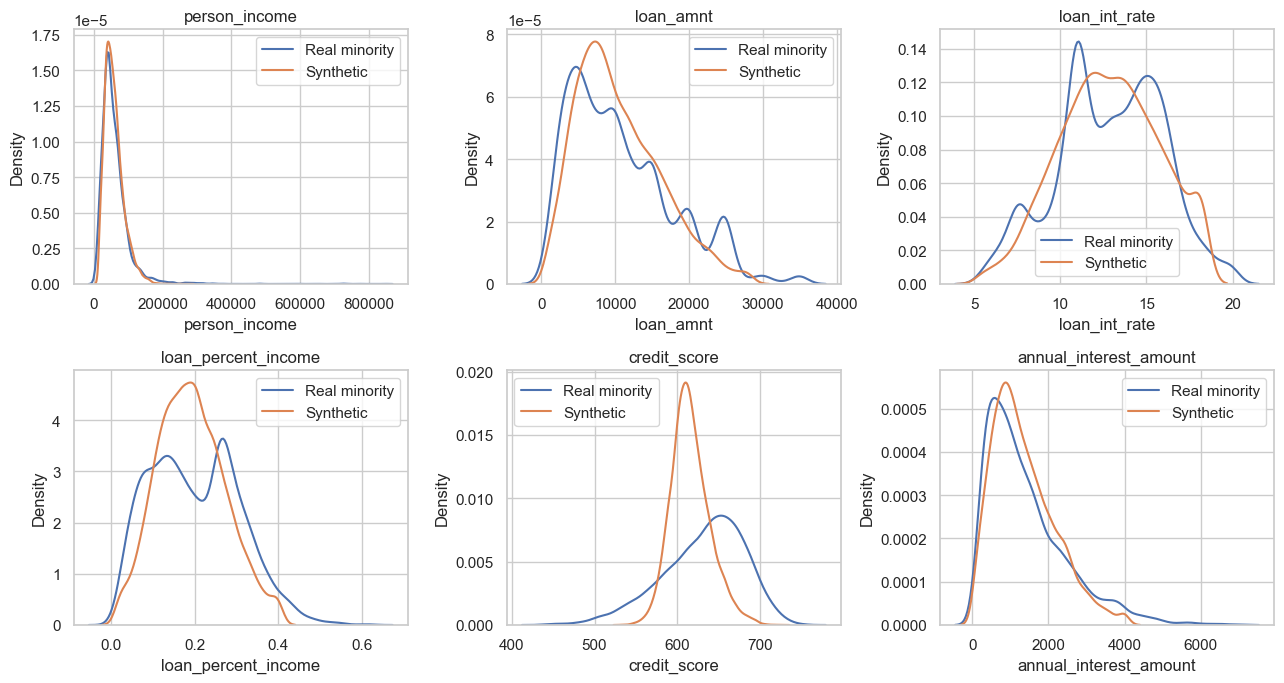

Mean absolute correlation difference: 0.0950


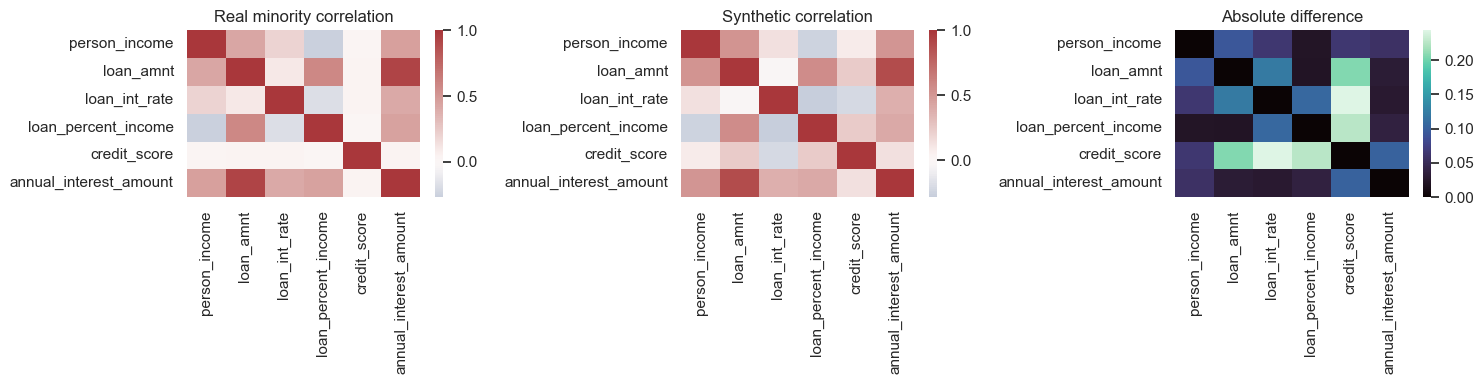

In [11]:
selected_continuous_for_validation = [
    col
    for col in [
        "person_income",
        "loan_amnt",
        "loan_int_rate",
        "loan_percent_income",
        "credit_score",
        "annual_interest_amount",
    ]
    if col in continuous_cols
]

real_stats = X_train_minority[selected_continuous_for_validation].agg(["mean", "std"]).T
synth_stats = synthetic_pool[selected_continuous_for_validation].agg(["mean", "std"]).T
continuous_validation_summary = real_stats.join(
    synth_stats,
    lsuffix="_real_minority",
    rsuffix="_synthetic",
)
continuous_validation_summary["abs_mean_diff"] = (
    continuous_validation_summary["mean_real_minority"]
    - continuous_validation_summary["mean_synthetic"]
).abs()
continuous_validation_summary = continuous_validation_summary.reset_index(names="feature")
continuous_validation_summary.insert(1, "feature_type", "continuous")
display(continuous_validation_summary.round(4))

binary_rate_summary = pd.DataFrame(
    {
        "real_minority_rate": X_train_minority[binary_cols].mean(),
        "synthetic_rate": synthetic_pool[binary_cols].mean(),
    }
)
binary_rate_summary["abs_rate_diff"] = (
    binary_rate_summary["real_minority_rate"] - binary_rate_summary["synthetic_rate"]
).abs()
binary_rate_summary = binary_rate_summary.reset_index(names="feature")
binary_rate_summary.insert(1, "feature_type", "binary")
display(binary_rate_summary.sort_values("abs_rate_diff", ascending=False).head(10).round(4))

synthetic_validation_summary = pd.concat(
    [continuous_validation_summary, binary_rate_summary],
    axis=0,
    ignore_index=True,
    sort=False,
)
synthetic_validation_summary.to_csv(OUTPUT_DIR / "synthetic_validation_summary.csv", index=False)

fig, axes = plt.subplots(2, 3, figsize=(13, 7))
for ax, col in zip(axes.ravel(), selected_continuous_for_validation):
    sns.kdeplot(X_train_minority[col], label="Real minority", ax=ax)
    sns.kdeplot(synthetic_pool[col], label="Synthetic", ax=ax)
    ax.set_title(col)
    ax.legend()
for ax in axes.ravel()[len(selected_continuous_for_validation):]:
    ax.axis("off")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "synthetic_distribution_checks.png", dpi=160)
plt.show()

corr_real = X_train_minority[selected_continuous_for_validation].corr()
corr_synth = synthetic_pool[selected_continuous_for_validation].corr()
corr_diff = (corr_real - corr_synth).abs()
print(f"Mean absolute correlation difference: {corr_diff.values[np.triu_indices_from(corr_diff, k=1)].mean():.4f}")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.heatmap(corr_real, cmap="vlag", center=0, ax=axes[0])
axes[0].set_title("Real minority correlation")
sns.heatmap(corr_synth, cmap="vlag", center=0, ax=axes[1])
axes[1].set_title("Synthetic correlation")
sns.heatmap(corr_diff, cmap="mako", ax=axes[2])
axes[2].set_title("Absolute difference")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "synthetic_correlation_check.png", dpi=160)
plt.show()

### Train with Synthetic Minority Samples



In [12]:
synthetic_models = {}
synthetic_training_sets = {}
synthetic_ratios = [0.25, 0.50, 1.00]

for ratio in synthetic_ratios:
    n_synthetic = int(len(X_train_minority) * ratio)
    X_synth = synthetic_pool.iloc[:n_synthetic].copy()
    y_synth = pd.Series(np.ones(n_synthetic, dtype=int), name=TARGET_COL)

    X_augmented = pd.concat([X_train, X_synth], axis=0, ignore_index=True)
    y_augmented = pd.concat([y_train.reset_index(drop=True), y_synth], axis=0, ignore_index=True)

    model = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("classifier", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)),
        ]
    )
    model.fit(X_augmented, y_augmented)

    method_name = f"{generator_used} synthetic ratio {ratio:.2f}"
    synthetic_models[method_name] = model
    synthetic_training_sets[method_name] = (X_augmented, y_augmented)
    fitted_models[f"Stage 3: {method_name}"] = model

    metrics = evaluate_binary_model(
        "Stage 3",
        method_name,
        model,
        X_test,
        y_test,
        notes="Synthetic minority samples appended only to training data.",
    )
    display_metrics(metrics)
    print(f"Training distribution for {method_name}: {y_augmented.value_counts().sort_index().to_dict()}")

stage3_table = results_frame().query("stage == 'Stage 3'").copy()
stage3_table["selection_score"] = stage3_table.apply(selection_score, axis=1)
stage3_table = stage3_table.sort_values(["selection_score", "pr_auc", "f1", "recall"], ascending=False)
display(stage3_table.round(4))

best_stage3_method = stage3_table.iloc[0]["method"]
best_stage3_model = synthetic_models[best_stage3_method]
print(f"Best Stage 3 method by selection score: {best_stage3_method}")

current_test_fingerprint = pd.util.hash_pandas_object(
    pd.concat([X_test.reset_index(drop=True), y_test.reset_index(drop=True)], axis=1),
    index=True,
).sum()
assert current_test_fingerprint == original_test_fingerprint
print("Verified: the test set fingerprint is unchanged after resampling and synthetic generation.")

save_results_table()

,stage,method,accuracy,balanced_accuracy,precision,recall,f1,macro_f1,weighted_f1,roc_auc,pr_auc,notes
0,Stage 3,Tabular VAE synthetic ratio 0.25,0.8993,0.8669,0.7556,0.8085,0.7812,0.8579,0.9005,0.9569,0.867,Synthetic minority samples appended only to tr...


Training distribution for Tabular VAE synthetic ratio 0.25: {0: 27994, 1: 10000}


,stage,method,accuracy,balanced_accuracy,precision,recall,f1,macro_f1,weighted_f1,roc_auc,pr_auc,notes
0,Stage 3,Tabular VAE synthetic ratio 0.50,0.8959,0.8688,0.7397,0.82,0.7778,0.8549,0.8977,0.956,0.8634,Synthetic minority samples appended only to tr...


Training distribution for Tabular VAE synthetic ratio 0.50: {0: 27994, 1: 12000}


,stage,method,accuracy,balanced_accuracy,precision,recall,f1,macro_f1,weighted_f1,roc_auc,pr_auc,notes
0,Stage 3,Tabular VAE synthetic ratio 1.00,0.8903,0.874,0.7142,0.8445,0.7739,0.8507,0.8934,0.9543,0.8564,Synthetic minority samples appended only to tr...


Training distribution for Tabular VAE synthetic ratio 1.00: {0: 27994, 1: 16000}


,stage,method,accuracy,balanced_accuracy,precision,recall,f1,macro_f1,weighted_f1,roc_auc,pr_auc,notes,selection_score
9,Stage 3,Tabular VAE synthetic ratio 1.00,0.8903,0.8740,0.7142,0.8445,0.7739,0.8507,0.8934,0.9543,0.8564,Synthetic minority samples appended only to tr...,0.8328
8,Stage 3,Tabular VAE synthetic ratio 0.50,0.8959,0.8688,0.7397,0.8200,0.7778,0.8549,0.8977,0.9560,0.8634,Synthetic minority samples appended only to tr...,0.8312
7,Stage 3,Tabular VAE synthetic ratio 0.25,0.8993,0.8669,0.7556,0.8085,0.7812,0.8579,0.9005,0.9569,0.8670,Synthetic minority samples appended only to tr...,0.8309


Best Stage 3 method by selection score: Tabular VAE synthetic ratio 1.00
Verified: the test set fingerprint is unchanged after resampling and synthetic generation.


,stage,method,accuracy,balanced_accuracy,precision,recall,f1,macro_f1,weighted_f1,roc_auc,pr_auc,notes
0,Stage 0,Dummy most_frequent,0.777753,0.500000,0.000000,0.0000,0.000000,0.437492,0.680522,0.500000,0.222247,Naive majority-class reference.
1,Stage 0,Simple logistic,0.904878,0.862246,0.786286,0.7855,0.785893,0.862375,0.904861,0.957396,0.868396,Logistic regression before explicit imbalance ...
2,Stage 1,Cleaned LR pipeline,0.904878,0.862246,0.786286,0.7855,0.785893,0.862375,0.904861,0.957396,0.868396,Leakage-safe preprocessing plus logistic regre...
3,Stage 2,Class weight balanced,0.861207,0.882203,0.628201,0.9200,0.746602,0.825516,0.869353,0.957325,0.865984,Imbalance strategy applied only on training data.
4,Stage 2,RandomOverSampler,0.860762,0.881917,0.627344,0.9200,0.745996,0.825046,0.868958,0.957242,0.865671,Imbalance strategy applied only on training data.
5,Stage 2,SMOTE,0.861429,0.879846,0.629872,0.9130,0.745458,0.825130,0.869388,0.956980,0.865610,Imbalance strategy applied only on training data.
6,Stage 2,RandomUnderSampler,0.862985,0.883703,0.631471,0.9210,0.749237,0.827489,0.870959,0.957463,0.865333,Imbalance strategy applied only on training data.
7,Stage 3,Tabular VAE synthetic ratio 0.25,0.899322,0.866888,0.755607,0.8085,0.781159,0.857891,0.900516,0.956899,0.867049,Synthetic minority samples appended only to tr...
8,Stage 3,Tabular VAE synthetic ratio 0.50,0.895877,0.868780,0.739738,0.8200,0.777804,0.854906,0.897737,0.955973,0.863441,Synthetic minority samples appended only to tr...
9,Stage 3,Tabular VAE synthetic ratio 1.00,0.890321,0.873957,0.714165,0.8445,0.773883,0.850743,0.893439,0.954298,0.856364,Synthetic minority samples appended only to tr...


## Select the Best Model from Stages 1-3

XAI should explain the best practical model from the workflow before any optional simplification.


,stage,method,accuracy,balanced_accuracy,precision,recall,f1,macro_f1,weighted_f1,roc_auc,pr_auc,notes,selection_score
6,Stage 2,RandomUnderSampler,0.8630,0.8837,0.6315,0.9210,0.7492,0.8275,0.8710,0.9575,0.8653,Imbalance strategy applied only on training data.,0.8502
3,Stage 2,Class weight balanced,0.8612,0.8822,0.6282,0.9200,0.7466,0.8255,0.8694,0.9573,0.8660,Imbalance strategy applied only on training data.,0.8496
4,Stage 2,RandomOverSampler,0.8608,0.8819,0.6273,0.9200,0.7460,0.8250,0.8690,0.9572,0.8657,Imbalance strategy applied only on training data.,0.8493
5,Stage 2,SMOTE,0.8614,0.8798,0.6299,0.9130,0.7455,0.8251,0.8694,0.9570,0.8656,Imbalance strategy applied only on training data.,0.8474
9,Stage 3,Tabular VAE synthetic ratio 1.00,0.8903,0.8740,0.7142,0.8445,0.7739,0.8507,0.8934,0.9543,0.8564,Synthetic minority samples appended only to tr...,0.8328
8,Stage 3,Tabular VAE synthetic ratio 0.50,0.8959,0.8688,0.7397,0.8200,0.7778,0.8549,0.8977,0.9560,0.8634,Synthetic minority samples appended only to tr...,0.8312
7,Stage 3,Tabular VAE synthetic ratio 0.25,0.8993,0.8669,0.7556,0.8085,0.7812,0.8579,0.9005,0.9569,0.8670,Synthetic minority samples appended only to tr...,0.8309
2,Stage 1,Cleaned LR pipeline,0.9049,0.8622,0.7863,0.7855,0.7859,0.8624,0.9049,0.9574,0.8684,Leakage-safe preprocessing plus logistic regre...,0.8270


Selected model for XAI: Stage 2: RandomUnderSampler
Saved selected final model to: models\best_bonus_pipeline.joblib


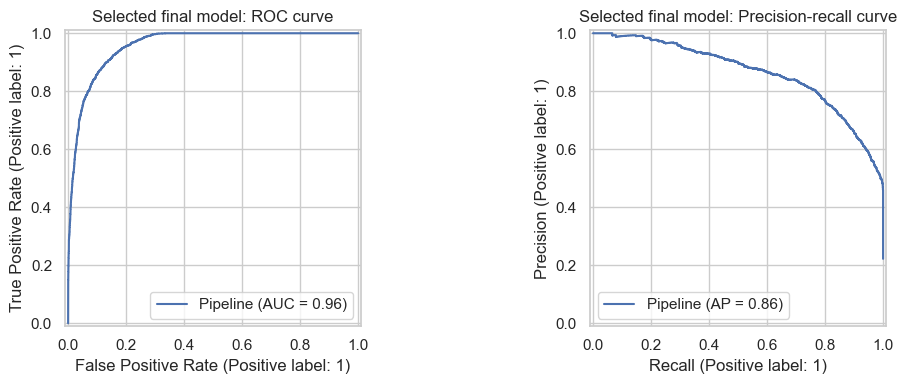

In [13]:
candidate_table = results_frame().query("stage in ['Stage 1', 'Stage 2', 'Stage 3']").copy()
candidate_table["selection_score"] = candidate_table.apply(selection_score, axis=1)
candidate_table = candidate_table.sort_values(
    ["selection_score", "pr_auc", "f1", "recall"],
    ascending=False,
)
display(candidate_table.round(4))

best_row = candidate_table.iloc[0]
best_label = f"{best_row['stage']}: {best_row['method']}"
final_model = fitted_models[best_label]
print(f"Selected model for XAI: {best_label}")

best_model_path = MODEL_DIR / "best_bonus_pipeline.joblib"
joblib.dump(final_model, best_model_path)
print(f"Saved selected final model to: {best_model_path}")

plot_roc_pr_curves(final_model, X_test, y_test, "Selected final model", "final_model_roc_pr_curves.png")

## Stage 4: XAI Analysis

A model used in a loan-related task should be explainable. We inspect global feature importance, local explanations, and error cases.


,feature,coefficient,abs_coefficient
15,default_interest_interaction,-3.3702,3.3702
18,previous_loan_defaults_on_file,-2.7020,2.7020
5,loan_percent_income,2.6076,2.6076
25,person_home_ownership_own,-2.4467,2.4467
12,interest_burden,-1.5182,1.5182
16,annual_interest_amount,0.9347,0.9347
9,log_loan_amnt,-0.8662,0.8662
4,loan_int_rate,0.7779,0.7779
30,loan_intent_venture,-0.7701,0.7701
28,loan_intent_homeimprovement,0.6915,0.6915


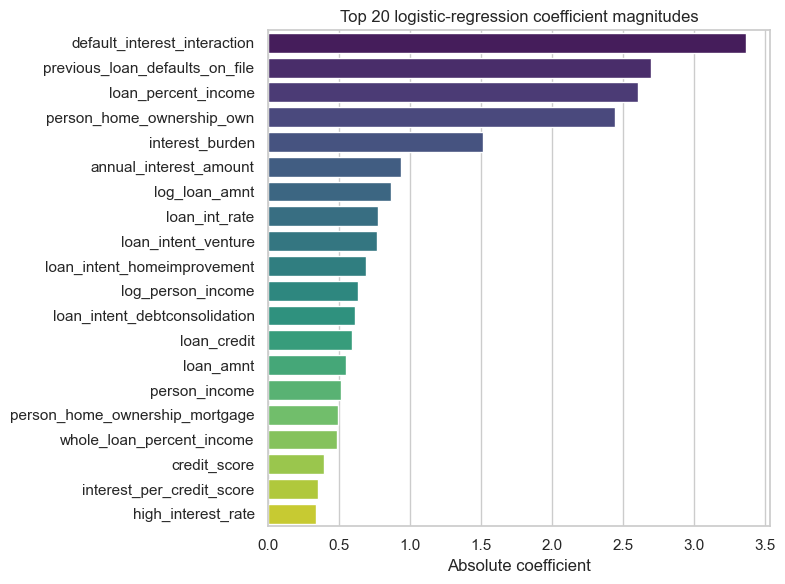

In [14]:
final_preprocessor = final_model.named_steps["preprocessor"]
final_classifier = final_model.named_steps["classifier"]
feature_names = final_preprocessor.get_feature_names_out()

background_size = min(500, len(X_train))
explain_size = min(300, len(X_test))
X_background = X_train.sample(background_size, random_state=RANDOM_STATE)
X_explain = X_test.sample(explain_size, random_state=RANDOM_STATE)
X_background_transformed = final_preprocessor.transform(X_background)
X_explain_transformed = final_preprocessor.transform(X_explain)

coefficient_importance = pd.DataFrame(
    {
        "feature": feature_names,
        "coefficient": final_classifier.coef_[0],
        "abs_coefficient": np.abs(final_classifier.coef_[0]),
    }
).sort_values("abs_coefficient", ascending=False)
display(coefficient_importance.head(20).round(4))
coefficient_importance.to_csv(OUTPUT_DIR / "xai_logistic_coefficients.csv", index=False)

fig, ax = plt.subplots(figsize=(8, 6))
sns.barplot(
    data=coefficient_importance.head(20),
    x="abs_coefficient",
    y="feature",
    ax=ax,
    palette="viridis",
)
ax.set_title("Top 20 logistic-regression coefficient magnitudes")
ax.set_xlabel("Absolute coefficient")
ax.set_ylabel("")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "coefficient_importance.png", dpi=160)
plt.show()

### SHAP Global and Local Explanations

WSHAP gives a model-specific explanation of how transformed features push predictions up or down.

The summary plot shows global drivers, and waterfall plots show local drivers for individual loan records. If SHAP fails in another environment, the notebook records the error and continues with other explanation methods.

Background dataset has 500 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=500 when initializing the masker.


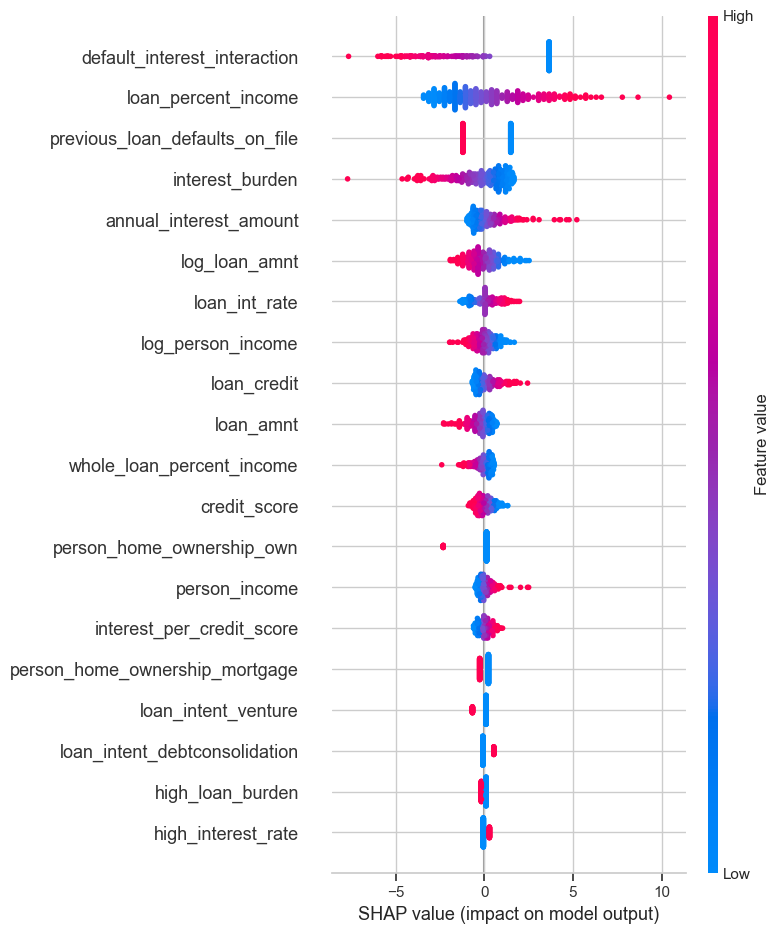

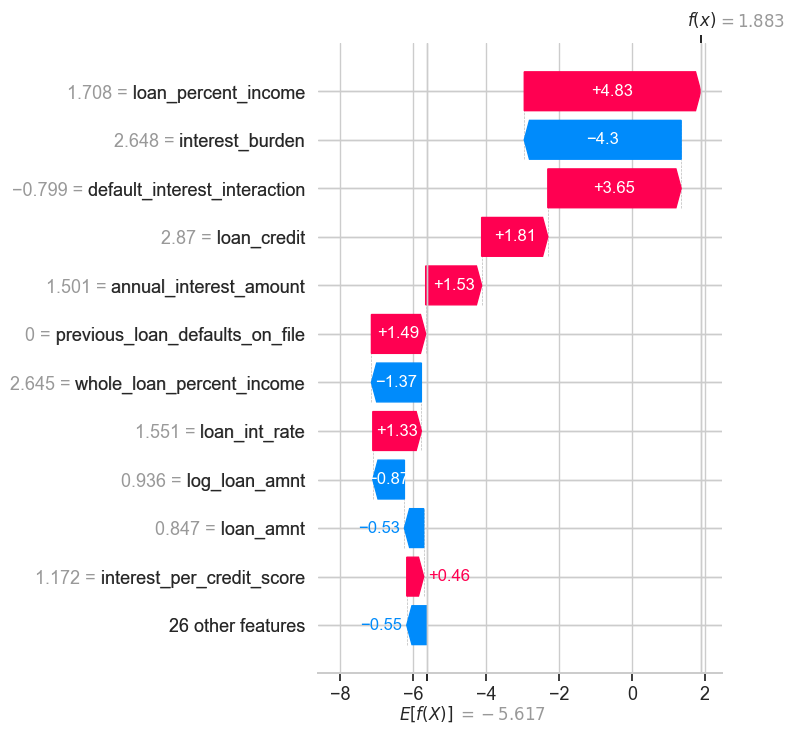

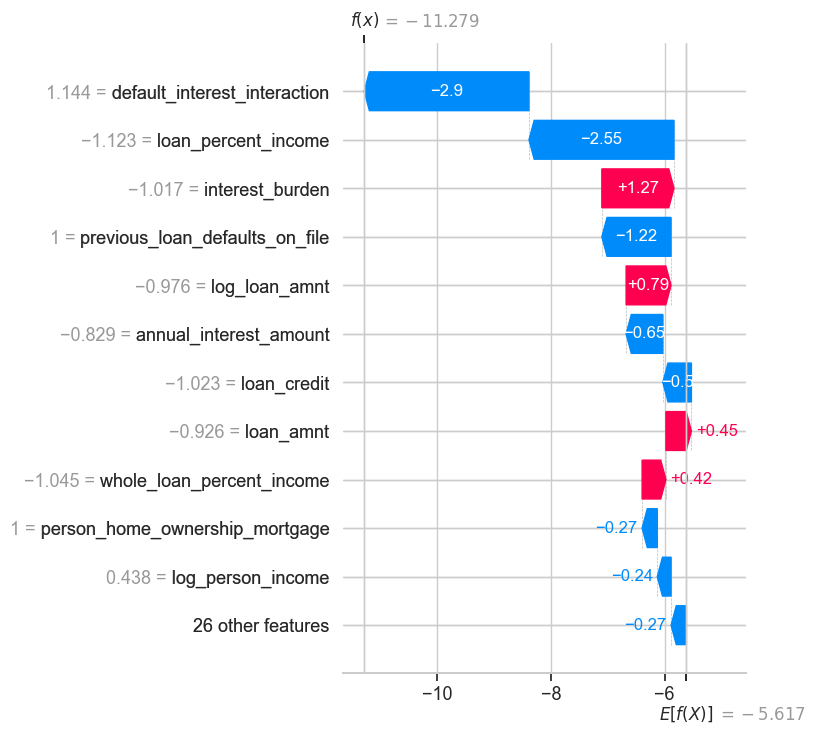

{'ran': True, 'error': None}


In [15]:
shap_status = {"ran": False, "error": None}
shap_values = None

if SHAP_AVAILABLE:
    try:
        shap_explainer = shap.LinearExplainer(
            final_classifier,
            X_background_transformed,
            feature_names=feature_names,
        )
        shap_values = shap_explainer(X_explain_transformed)

        plt.figure(figsize=(9, 6))
        shap.summary_plot(
            shap_values.values,
            X_explain_transformed,
            feature_names=feature_names,
            show=False,
            max_display=20,
        )
        plt.tight_layout()
        plt.savefig(FIGURE_DIR / "shap_summary.png", dpi=160, bbox_inches="tight")
        plt.show()

        for i, sample_position in enumerate([0, min(1, explain_size - 1)]):
            shap.plots.waterfall(shap_values[sample_position], max_display=12, show=False)
            plt.tight_layout()
            plt.savefig(FIGURE_DIR / f"shap_waterfall_sample_{i + 1}.png", dpi=160, bbox_inches="tight")
            plt.show()

        shap_status["ran"] = True
    except Exception as exc:
        shap_status["error"] = repr(exc)
else:
    shap_status["error"] = SHAP_IMPORT_ERROR

print(shap_status)

### LIME Local Explanations

LIME gives a local, model-agnostic explanation around specific examples.

We compare one true positive, one false positive, and one false negative when those cases exist. This is useful for understanding both correct minority detection and error patterns.

Selected LIME cases: {'true_positive': 6, 'false_positive': 0, 'false_negative': 27}


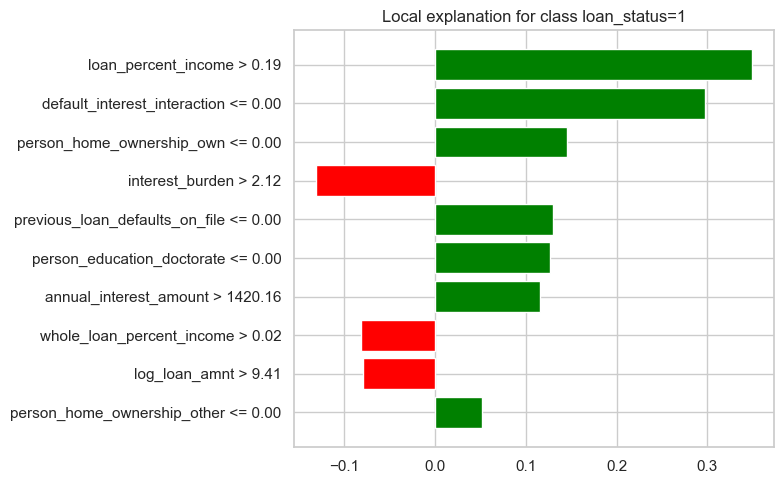

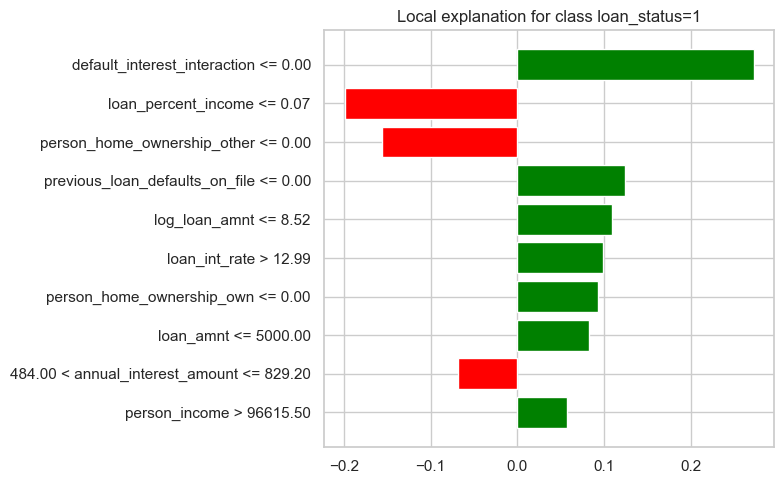

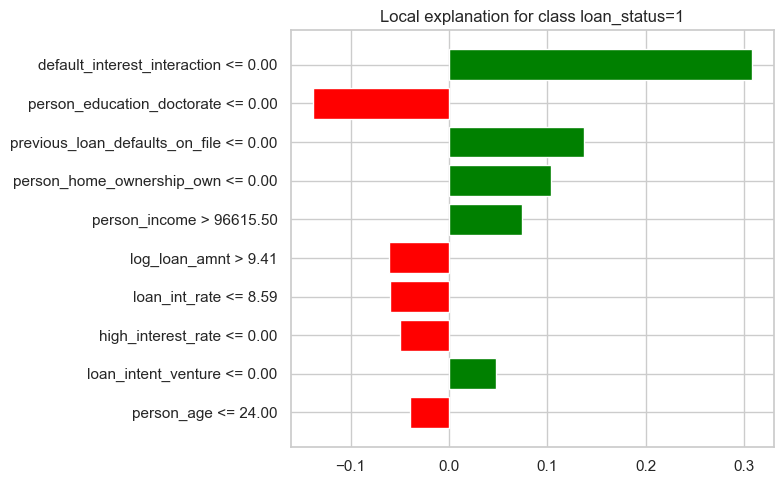

,case,test_position,feature_rule,lime_weight_for_class_1,html_file
0,true_positive,6,loan_percent_income > 0.19,0.349259,outputs\lime_true_positive.html
1,true_positive,6,default_interest_interaction <= 0.00,0.297427,outputs\lime_true_positive.html
2,true_positive,6,person_home_ownership_own <= 0.00,0.145112,outputs\lime_true_positive.html
3,true_positive,6,interest_burden > 2.12,-0.130480,outputs\lime_true_positive.html
4,true_positive,6,previous_loan_defaults_on_file <= 0.00,0.130381,outputs\lime_true_positive.html
5,true_positive,6,person_education_doctorate <= 0.00,0.126421,outputs\lime_true_positive.html
6,true_positive,6,annual_interest_amount > 1420.16,0.115325,outputs\lime_true_positive.html
7,true_positive,6,whole_loan_percent_income > 0.02,-0.080966,outputs\lime_true_positive.html
8,true_positive,6,log_loan_amnt > 9.41,-0.078857,outputs\lime_true_positive.html
9,true_positive,6,person_home_ownership_other <= 0.00,0.051459,outputs\lime_true_positive.html


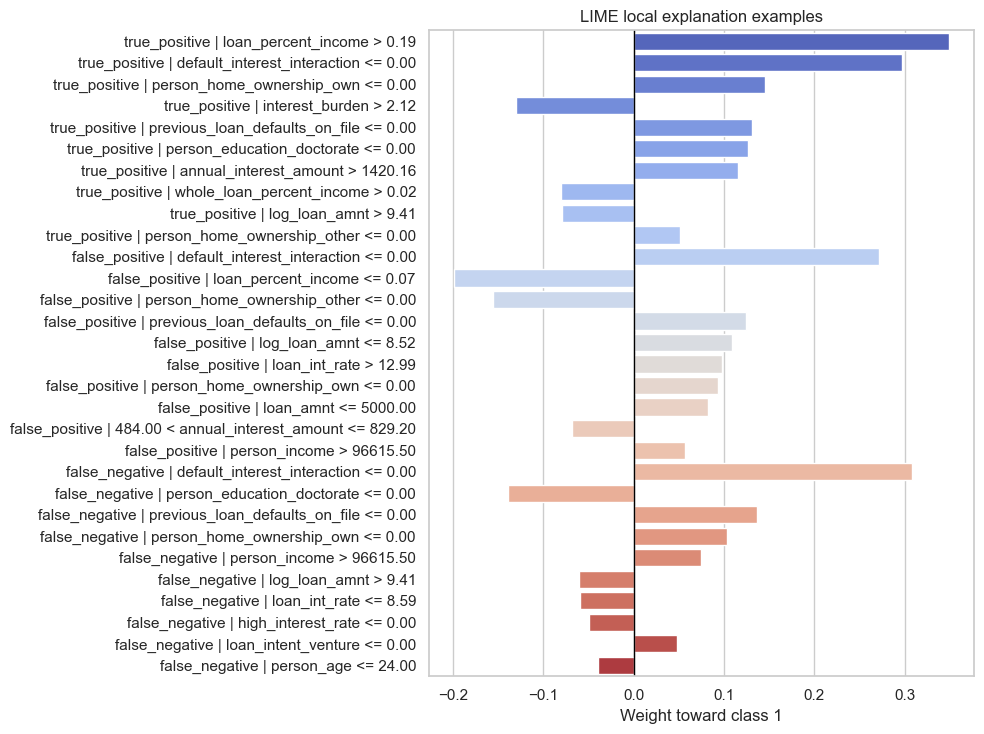

{'ran': True, 'error': None, 'cases': ['true_positive', 'false_positive', 'false_negative']}


In [16]:
final_pred = final_model.predict(X_test)
final_proba = positive_scores(final_model, X_test)

case_candidates = {
    "true_positive": np.where((y_test.to_numpy() == 1) & (final_pred == 1))[0],
    "false_positive": np.where((y_test.to_numpy() == 0) & (final_pred == 1))[0],
    "false_negative": np.where((y_test.to_numpy() == 1) & (final_pred == 0))[0],
}
selected_lime_cases = {
    name: int(indices[0])
    for name, indices in case_candidates.items()
    if len(indices) > 0
}
print(f"Selected LIME cases: {selected_lime_cases}")

lime_status = {"ran": False, "error": None, "cases": list(selected_lime_cases)}
lime_records = []

if LIME_AVAILABLE and selected_lime_cases:
    try:
        lime_explainer = LimeTabularExplainer(
            training_data=X_train.to_numpy(),
            feature_names=X_train.columns.tolist(),
            class_names=["loan_status=0", "loan_status=1"],
            mode="classification",
            discretize_continuous=True,
            random_state=RANDOM_STATE,
        )

        def lime_predict_fn(array):
            frame = pd.DataFrame(array, columns=X_train.columns)
            return final_model.predict_proba(frame)

        for case_name, row_position in selected_lime_cases.items():
            explanation = lime_explainer.explain_instance(
                X_test.iloc[row_position].to_numpy(),
                lime_predict_fn,
                num_features=10,
                num_samples=1000,
            )
            html_path = OUTPUT_DIR / f"lime_{case_name}.html"
            explanation.save_to_file(html_path)

            fig = explanation.as_pyplot_figure(label=1)
            fig.set_size_inches(8, 5)
            fig.tight_layout()
            fig.savefig(FIGURE_DIR / f"lime_{case_name}.png", dpi=160, bbox_inches="tight")
            plt.show()

            for feature, weight in explanation.as_list(label=1):
                lime_records.append(
                    {
                        "case": case_name,
                        "test_position": row_position,
                        "feature_rule": feature,
                        "lime_weight_for_class_1": weight,
                        "html_file": str(html_path),
                    }
                )

        lime_df = pd.DataFrame(lime_records)
        display(lime_df.head(30))
        lime_df.to_csv(OUTPUT_DIR / "lime_local_explanations.csv", index=False)

        if not lime_df.empty:
            fig, ax = plt.subplots(figsize=(10, max(4, 0.25 * len(lime_df.head(30)))))
            plot_df = lime_df.head(30).copy()
            plot_df["label"] = plot_df["case"] + " | " + plot_df["feature_rule"]
            sns.barplot(data=plot_df, x="lime_weight_for_class_1", y="label", ax=ax, palette="coolwarm")
            ax.axvline(0, color="black", linewidth=1)
            ax.set_title("LIME local explanation examples")
            ax.set_xlabel("Weight toward class 1")
            ax.set_ylabel("")
            fig.tight_layout()
            fig.savefig(FIGURE_DIR / "lime_examples.png", dpi=160, bbox_inches="tight")
            plt.show()

        lime_status["ran"] = True
    except Exception as exc:
        lime_status["error"] = repr(exc)
else:
    lime_status["error"] = LIME_IMPORT_ERROR if not LIME_AVAILABLE else "No suitable local cases found."

print(lime_status)

### ELI5 or Permutation-Importance Fallback

ELI5 can explain linear model weights directly. If it is incompatible with the fitted model or environment, permutation importance is a reliable sklearn fallback.
We get another global explanation view and explicitly document which method ran.

Explained as: linear model

Features with largest coefficients.
Caveats:
1. Be careful with features which are not
   independent - weights don't show their importance.
2. If scale of input features is different then scale of coefficients
   will also be different, making direct comparison between coefficient values
   incorrect.
3. Depending on regularization, rare features sometimes may have high
   coefficients; this doesn't mean they contribute much to the
   classification result for most examples.

y=1 top features
Weight  Feature                       
------  ------------------------------
+2.608  loan_percent_income           
+0.935  annual_interest_amount        
+0.778  loan_int_rate                 
+0.692  loan_intent_homeimprovement   
+0.614  loan_intent_debtconsolidation 
+0.595  loan_credit                   
+0.516  person_income                 
+0.354  interest_per_credit_score     
+0.343  high_interest_rate            
+0.331  loan_intent_medical           
+0.13

,feature,importance_mean,importance_std
6,loan_percent_income,0.36500,0.01846
29,default_interest_interaction,0.25713,0.02003
32,annual_interest_amount,0.10300,0.01908
9,previous_loan_defaults_on_file,0.07897,0.01412
5,loan_int_rate,0.07732,0.01027
25,loan_credit,0.06660,0.01523
26,interest_burden,0.06447,0.01293
23,log_loan_amnt,0.06264,0.00905
22,log_person_income,0.04209,0.00795
16,person_home_ownership_own,0.03403,0.00993


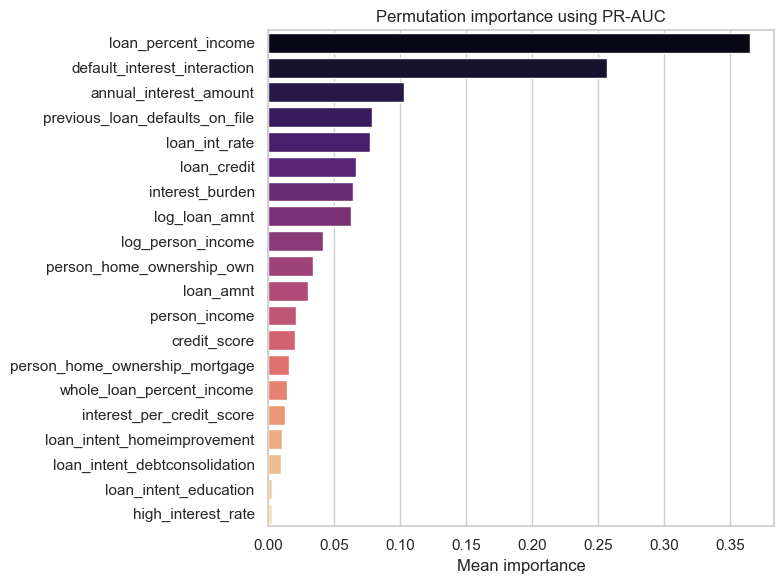

In [17]:
eli5_status = {"ran": False, "error": None}

if ELI5_AVAILABLE:
    try:
        eli5_text = eli5.format_as_text(
            eli5.explain_weights(final_classifier, feature_names=list(feature_names), top=25)
        )
        (OUTPUT_DIR / "eli5_weights.txt").write_text(eli5_text, encoding="utf-8")
        print(eli5_text[:2000])
        eli5_status["ran"] = True
    except Exception as exc:
        eli5_status["error"] = repr(exc)
else:
    eli5_status["error"] = ELI5_IMPORT_ERROR

print(eli5_status)

permutation_sample_size = min(1000, len(X_test))
X_perm = X_test.sample(permutation_sample_size, random_state=RANDOM_STATE)
y_perm = y_test.loc[X_perm.index]
perm = permutation_importance(
    final_model,
    X_perm,
    y_perm,
    n_repeats=5,
    random_state=RANDOM_STATE,
    scoring="average_precision",
)
permutation_df = pd.DataFrame(
    {
        "feature": X_perm.columns,
        "importance_mean": perm.importances_mean,
        "importance_std": perm.importances_std,
    }
).sort_values("importance_mean", ascending=False)
display(permutation_df.head(20).round(5))
permutation_df.to_csv(OUTPUT_DIR / "permutation_importance.csv", index=False)

fig, ax = plt.subplots(figsize=(8, 6))
sns.barplot(data=permutation_df.head(20), x="importance_mean", y="feature", ax=ax, palette="magma")
ax.set_title("Permutation importance using PR-AUC")
ax.set_xlabel("Mean importance")
ax.set_ylabel("")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "permutation_importance.png", dpi=160)
plt.show()

### Error Analysis for Wrong Predictions

Aggregate metrics hide the details of individual mistakes.

By inspecting at least three wrong predictions, we can see whether errors are related to borderline probabilities, high loan burden, income, credit features, or other model drivers.

In [18]:
wrong_positions = np.where(final_pred != y_test.to_numpy())[0]
fp_positions = np.where((y_test.to_numpy() == 0) & (final_pred == 1))[0]
fn_positions = np.where((y_test.to_numpy() == 1) & (final_pred == 0))[0]

selected_error_positions = []

if len(fp_positions) > 0:
    selected_error_positions.append(int(fp_positions[0]))
if len(fn_positions) > 0:
    selected_error_positions.append(int(fn_positions[0]))

for arr in [wrong_positions]:
    for pos in arr:
        if int(pos) not in selected_error_positions:
            selected_error_positions.append(int(pos))
        if len(selected_error_positions) >= 3:
            break
    if len(selected_error_positions) >= 3:
        break

if len(selected_error_positions) < 3:
    raise RuntimeError("Fewer than 3 wrong predictions were found; cannot complete required error analysis.")

transformed_test = final_preprocessor.transform(X_test.iloc[selected_error_positions])
coef = final_classifier.coef_[0]
error_rows = []

for local_i, test_position in enumerate(selected_error_positions):
    row = X_test.iloc[test_position]
    true_label = int(y_test.iloc[test_position])
    pred_label = int(final_pred[test_position])
    proba = float(final_proba[test_position])
    contributions = transformed_test[local_i] * coef
    top_idx = np.argsort(np.abs(contributions))[::-1][:8]
    top_features = []
    top_values = []
    top_contributions = []
    for idx in top_idx:
        feature = str(feature_names[idx])
        top_features.append(feature)
        if feature in row.index:
            top_values.append(f"{feature}={row[feature]:.4g}")
        else:
            top_values.append(f"{feature}=transformed")
        top_contributions.append(f"{feature}:{contributions[idx]:.4f}")

    if pred_label == 1 and true_label == 0:
        likely_reason = "False positive: features pushed the estimated risk above the decision threshold."
    elif pred_label == 0 and true_label == 1:
        likely_reason = "False negative: features did not push the estimated risk high enough for class 1."
    else:
        likely_reason = "Wrong prediction near the classifier decision boundary."

    error_rows.append(
        {
            "test_position": test_position,
            "true_label": true_label,
            "predicted_label": pred_label,
            "predicted_probability_class_1": proba,
            "top_feature_values": "; ".join(top_values),
            "top_model_contributions": "; ".join(top_contributions),
            "likely_reason_for_error": likely_reason,
            "possible_training_improvement": (
                "Tune threshold, collect more minority examples, test calibrated probabilities, "
                "and audit sensitive or proxy features before deployment."
            ),
        }
    )

error_analysis_df = pd.DataFrame(error_rows)
display(error_analysis_df)
error_analysis_df.to_csv(OUTPUT_DIR / "xai_error_analysis.csv", index=False)

,test_position,true_label,predicted_label,predicted_probability_class_1,top_feature_values,top_model_contributions,likely_reason_for_error,possible_training_improvement
0,0,0,1,0.861155,loan_percent_income=0.05; default_interest_int...,loan_percent_income:-2.9272; default_interest_...,False positive: features pushed the estimated ...,"Tune threshold, collect more minority examples..."
1,27,1,0,0.174112,default_interest_interaction=0; log_loan_amnt=...,default_interest_interaction:2.6914; log_loan_...,False negative: features did not push the esti...,"Tune threshold, collect more minority examples..."
2,12,0,1,0.609235,default_interest_interaction=0; loan_percent_i...,default_interest_interaction:2.6914; loan_perc...,False positive: features pushed the estimated ...,"Tune threshold, collect more minority examples..."


### XAI-Informed Simplified Model

A simpler model can be easier to explain if it keeps most of the useful signal.

We train a top-feature model using the strongest coefficient features from the selected model, then compare performance with the full model. This tests the trade-off between interpretability and predictive strength.

In [19]:
top_n_features = 20
top_features = coefficient_importance.head(top_n_features)["feature"].tolist()
top_features = [feature for feature in top_features if feature in X_train.columns]

simple_continuous_cols = [col for col in continuous_cols if col in top_features]
simple_binary_cols = [col for col in binary_cols if col in top_features]

simple_preprocessor = ColumnTransformer(
    transformers=[
        ("continuous", continuous_pipeline, simple_continuous_cols),
        ("binary", binary_pipeline, simple_binary_cols),
    ],
    remainder="drop",
    verbose_feature_names_out=False,
)

simplified_model = Pipeline(
    steps=[
        ("preprocessor", simple_preprocessor),
        (
            "classifier",
            LogisticRegression(
                max_iter=1000,
                random_state=RANDOM_STATE,
                class_weight="balanced",
            ),
        ),
    ]
)
simplified_model.fit(X_train[top_features], y_train)
fitted_models["Stage 4: XAI-informed top-20 LR"] = simplified_model

stage4_metrics = evaluate_binary_model(
    "Stage 4",
    "XAI-informed top-20 LR",
    simplified_model,
    X_test[top_features],
    y_test,
    notes="Simplified model using top coefficient features and class weighting.",
)
display_metrics(stage4_metrics)

save_results_table()

,stage,method,accuracy,balanced_accuracy,precision,recall,f1,macro_f1,weighted_f1,roc_auc,pr_auc,notes
0,Stage 4,XAI-informed top-20 LR,0.8624,0.8828,0.6307,0.9195,0.7482,0.8268,0.8704,0.957,0.8641,Simplified model using top coefficient feature...


,stage,method,accuracy,balanced_accuracy,precision,recall,f1,macro_f1,weighted_f1,roc_auc,pr_auc,notes
0,Stage 0,Dummy most_frequent,0.777753,0.500000,0.000000,0.0000,0.000000,0.437492,0.680522,0.500000,0.222247,Naive majority-class reference.
1,Stage 0,Simple logistic,0.904878,0.862246,0.786286,0.7855,0.785893,0.862375,0.904861,0.957396,0.868396,Logistic regression before explicit imbalance ...
2,Stage 1,Cleaned LR pipeline,0.904878,0.862246,0.786286,0.7855,0.785893,0.862375,0.904861,0.957396,0.868396,Leakage-safe preprocessing plus logistic regre...
3,Stage 2,Class weight balanced,0.861207,0.882203,0.628201,0.9200,0.746602,0.825516,0.869353,0.957325,0.865984,Imbalance strategy applied only on training data.
4,Stage 2,RandomOverSampler,0.860762,0.881917,0.627344,0.9200,0.745996,0.825046,0.868958,0.957242,0.865671,Imbalance strategy applied only on training data.
5,Stage 2,SMOTE,0.861429,0.879846,0.629872,0.9130,0.745458,0.825130,0.869388,0.956980,0.865610,Imbalance strategy applied only on training data.
6,Stage 2,RandomUnderSampler,0.862985,0.883703,0.631471,0.9210,0.749237,0.827489,0.870959,0.957463,0.865333,Imbalance strategy applied only on training data.
7,Stage 3,Tabular VAE synthetic ratio 0.25,0.899322,0.866888,0.755607,0.8085,0.781159,0.857891,0.900516,0.956899,0.867049,Synthetic minority samples appended only to tr...
8,Stage 3,Tabular VAE synthetic ratio 0.50,0.895877,0.868780,0.739738,0.8200,0.777804,0.854906,0.897737,0.955973,0.863441,Synthetic minority samples appended only to tr...
9,Stage 3,Tabular VAE synthetic ratio 1.00,0.890321,0.873957,0.714165,0.8445,0.773883,0.850743,0.893439,0.954298,0.856364,Synthetic minority samples appended only to tr...


## Stage-by-Stage Comparison

The optional bonus asks for before/after comparisons after each major stage.


,stage,method,accuracy,balanced_accuracy,precision,recall,f1,macro_f1,weighted_f1,roc_auc,pr_auc,notes
0,Stage 0,Dummy most_frequent,0.7778,0.5000,0.0000,0.0000,0.0000,0.4375,0.6805,0.5000,0.2222,Naive majority-class reference.
1,Stage 0,Simple logistic,0.9049,0.8622,0.7863,0.7855,0.7859,0.8624,0.9049,0.9574,0.8684,Logistic regression before explicit imbalance ...
2,Stage 1,Cleaned LR pipeline,0.9049,0.8622,0.7863,0.7855,0.7859,0.8624,0.9049,0.9574,0.8684,Leakage-safe preprocessing plus logistic regre...
3,Stage 2,Class weight balanced,0.8612,0.8822,0.6282,0.9200,0.7466,0.8255,0.8694,0.9573,0.8660,Imbalance strategy applied only on training data.
4,Stage 2,RandomOverSampler,0.8608,0.8819,0.6273,0.9200,0.7460,0.8250,0.8690,0.9572,0.8657,Imbalance strategy applied only on training data.
5,Stage 2,SMOTE,0.8614,0.8798,0.6299,0.9130,0.7455,0.8251,0.8694,0.9570,0.8656,Imbalance strategy applied only on training data.
6,Stage 2,RandomUnderSampler,0.8630,0.8837,0.6315,0.9210,0.7492,0.8275,0.8710,0.9575,0.8653,Imbalance strategy applied only on training data.
7,Stage 3,Tabular VAE synthetic ratio 0.25,0.8993,0.8669,0.7556,0.8085,0.7812,0.8579,0.9005,0.9569,0.8670,Synthetic minority samples appended only to tr...
8,Stage 3,Tabular VAE synthetic ratio 0.50,0.8959,0.8688,0.7397,0.8200,0.7778,0.8549,0.8977,0.9560,0.8634,Synthetic minority samples appended only to tr...
9,Stage 3,Tabular VAE synthetic ratio 1.00,0.8903,0.8740,0.7142,0.8445,0.7739,0.8507,0.8934,0.9543,0.8564,Synthetic minority samples appended only to tr...


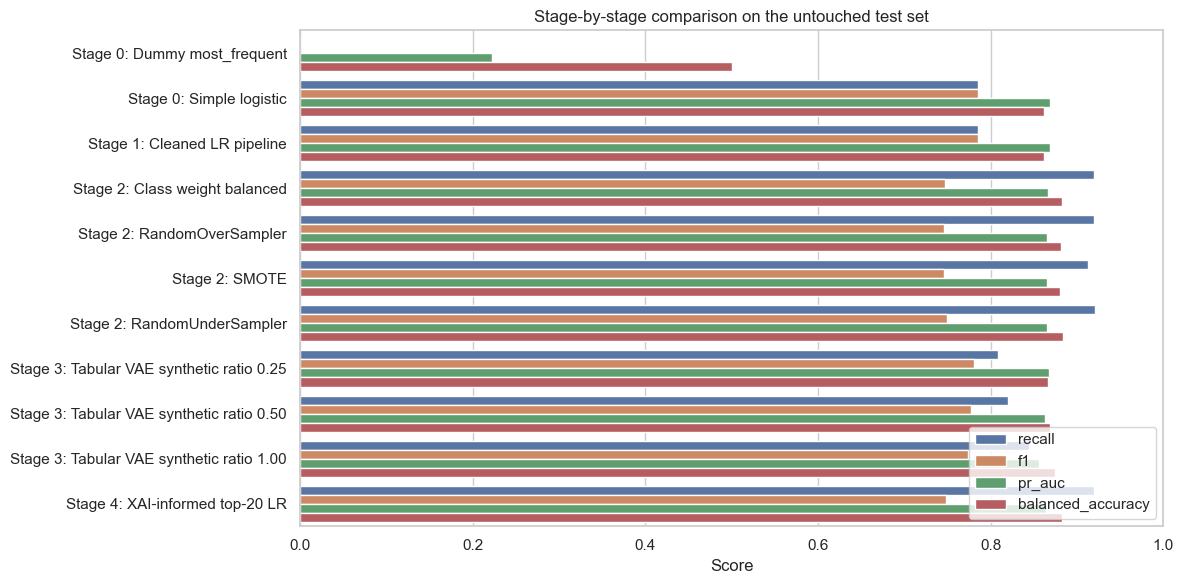

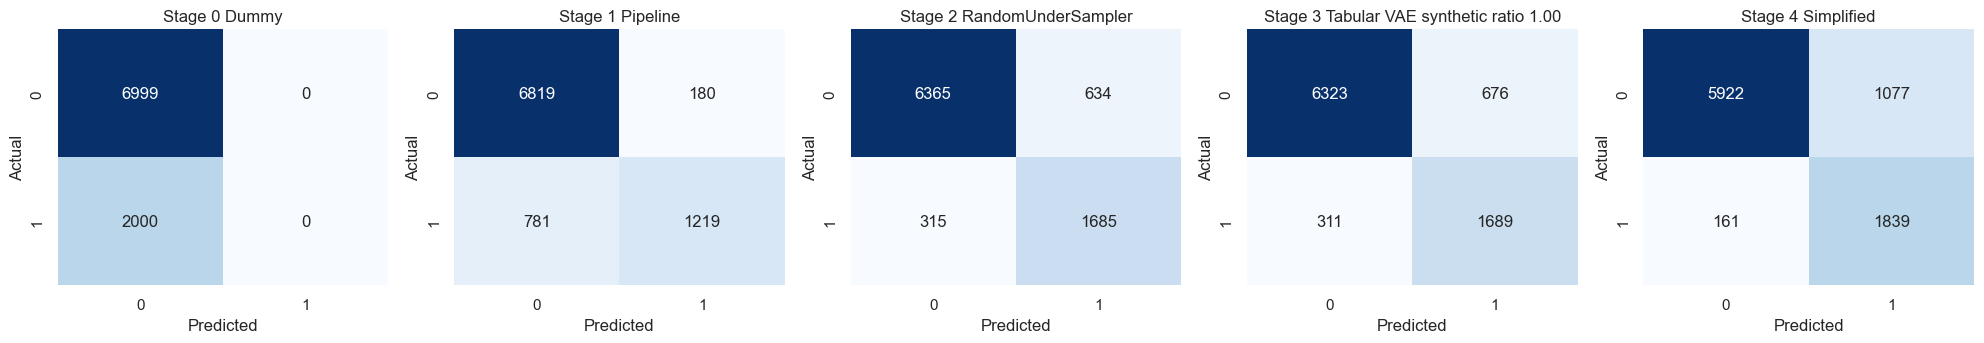

,stage,method,accuracy,balanced_accuracy,precision,recall,f1,macro_f1,weighted_f1,roc_auc,pr_auc,notes,selection_score
6,Stage 2,RandomUnderSampler,0.8630,0.8837,0.6315,0.9210,0.7492,0.8275,0.8710,0.9575,0.8653,Imbalance strategy applied only on training data.,0.8502
3,Stage 2,Class weight balanced,0.8612,0.8822,0.6282,0.9200,0.7466,0.8255,0.8694,0.9573,0.8660,Imbalance strategy applied only on training data.,0.8496
4,Stage 2,RandomOverSampler,0.8608,0.8819,0.6273,0.9200,0.7460,0.8250,0.8690,0.9572,0.8657,Imbalance strategy applied only on training data.,0.8493
10,Stage 4,XAI-informed top-20 LR,0.8624,0.8828,0.6307,0.9195,0.7482,0.8268,0.8704,0.9570,0.8641,Simplified model using top coefficient feature...,0.8490
5,Stage 2,SMOTE,0.8614,0.8798,0.6299,0.9130,0.7455,0.8251,0.8694,0.9570,0.8656,Imbalance strategy applied only on training data.,0.8474
9,Stage 3,Tabular VAE synthetic ratio 1.00,0.8903,0.8740,0.7142,0.8445,0.7739,0.8507,0.8934,0.9543,0.8564,Synthetic minority samples appended only to tr...,0.8328
8,Stage 3,Tabular VAE synthetic ratio 0.50,0.8959,0.8688,0.7397,0.8200,0.7778,0.8549,0.8977,0.9560,0.8634,Synthetic minority samples appended only to tr...,0.8312
7,Stage 3,Tabular VAE synthetic ratio 0.25,0.8993,0.8669,0.7556,0.8085,0.7812,0.8579,0.9005,0.9569,0.8670,Synthetic minority samples appended only to tr...,0.8309
1,Stage 0,Simple logistic,0.9049,0.8622,0.7863,0.7855,0.7859,0.8624,0.9049,0.9574,0.8684,Logistic regression before explicit imbalance ...,0.8270
2,Stage 1,Cleaned LR pipeline,0.9049,0.8622,0.7863,0.7855,0.7859,0.8624,0.9049,0.9574,0.8684,Leakage-safe preprocessing plus logistic regre...,0.8270


In [20]:
comparison_table = save_results_table()
comparison_table = comparison_table[
    [
        "stage",
        "method",
        "accuracy",
        "balanced_accuracy",
        "precision",
        "recall",
        "f1",
        "macro_f1",
        "weighted_f1",
        "roc_auc",
        "pr_auc",
        "notes",
    ]
]
display(comparison_table.round(4))
comparison_table.to_csv(OUTPUT_DIR / "bonus_stage_comparison.csv", index=False)

plot_stage_comparison(comparison_table)

confusion_model_items = [
    ("Stage 0 Dummy", dummy_model, X_test),
    ("Stage 1 Pipeline", stage1_model, X_test),
    (f"Stage 2 {best_stage2_method}", best_stage2_model, X_test),
    (f"Stage 3 {best_stage3_method}", best_stage3_model, X_test),
    ("Stage 4 Simplified", simplified_model, X_test[top_features]),
]
fig, axes = plt.subplots(1, len(confusion_model_items), figsize=(4 * len(confusion_model_items), 3.6))
for ax, (title, model, X_eval_for_model) in zip(axes, confusion_model_items):
    plot_confusion_matrix_for_model(model, X_eval_for_model, y_test, title, ax=ax)
fig.tight_layout()
fig.savefig(FIGURE_DIR / "confusion_matrices.png", dpi=160)
plt.show()

final_table_with_score = comparison_table.copy()
final_table_with_score["selection_score"] = final_table_with_score.apply(selection_score, axis=1)
display(final_table_with_score.sort_values("selection_score", ascending=False).round(4))

## Final Discussion


### What changed after data cleaning?

The dataset was already clean: no missing values, no duplicate rows, numeric columns, and a valid binary target. The main improvement from cleaning was reliability and reproducibility, not a large score change. The validation functions also protect the workflow from future data changes.

### What changed after the ML pipeline?

The sklearn pipeline made preprocessing leakage-safe by fitting imputers and scalers only on the training data. It also made the model serializable with joblib. The pipeline stage is more reproducible than ad hoc preprocessing.

### What changed after imbalance handling?

Class weighting and resampling methods usually trade precision for recall. This matters because the minority class is the riskier class to miss. Random oversampling, SMOTE, and undersampling were compared on the same untouched test set, so the differences come from training strategy rather than test-set manipulation.

### What changed after generative augmentation?

The tabular VAE generated minority-like samples and we tested several synthetic ratios. Synthetic samples can help recall by exposing the classifier to more minority-like cases, but they can also reduce precision or create unrealistic combinations. The validation plots and summaries are necessary because generated tabular data is approximate.

### What did XAI reveal?

Coefficients, SHAP, LIME, ELI5/permutation importance, and error analysis identify which features most strongly influence class-1 predictions. These explanations are useful for model debugging, but they are not causal proof.

### Important trade-offs and limitations

- The test set remained untouched throughout the workflow.
- Cleaning mostly improved reliability because the dataset was already clean.
- SMOTE can create fractional values in encoded-feature space, which may not always represent realistic applicants.
- VAE-generated samples are limited by the small architecture and short training schedule.
- XAI explanations are approximations and depend on the fitted model.
- Loan approval models can raise fairness and ethics concerns, especially when sensitive features or proxies are present.
- A simplified XAI-informed model may be easier to explain but can lose predictive detail.